In [12]:
# EDA 10 — Style Archetypes Rebuild
# Cell 1 — Imports, connection, constants, helpers, and artifact checks

import os
import json
import math
import warnings
from pathlib import Path
from decimal import Decimal

import numpy as np
import pandas as pd
import psycopg2

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------
# Locked season policy
# -------------------------------------------------------------------

DEV_SEASONS = [2022, 2023, 2024]
HOLDOUT_SEASON = 2025

# -------------------------------------------------------------------
# Artifact paths
# -------------------------------------------------------------------

ARTIFACT_DIR = Path("artifacts")

STYLE_TEMPO_VERDICT_PATH = ARTIFACT_DIR / "style_tempo_verdict.csv"
STYLE_TEMPO_SUMMARY_PATH = ARTIFACT_DIR / "style_tempo_summary.json"

assert STYLE_TEMPO_VERDICT_PATH.exists(), (
    "ERROR: artifacts/style_tempo_verdict.csv not found. "
    "Run rebuilt EDA 9 before EDA 10."
)

assert STYLE_TEMPO_SUMMARY_PATH.exists(), (
    "ERROR: artifacts/style_tempo_summary.json not found. "
    "Run rebuilt EDA 9 before EDA 10."
)

# -------------------------------------------------------------------
# DB connection
# -------------------------------------------------------------------

conn = psycopg2.connect(
    host="127.0.0.1",
    port=5455,
    dbname="postgres",
    user="postgres",
    password="postgres"
)

cur = conn.cursor()

# -------------------------------------------------------------------
# Canonical tier assignment — do not modify
# -------------------------------------------------------------------

P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

# -------------------------------------------------------------------
# General helpers
# -------------------------------------------------------------------

def fetch_df(sql, params=None):
    """
    Execute SQL with psycopg2 and return a DataFrame.
    Keeps the shared connection open for the full notebook.
    """
    cur.execute(sql, params)
    rows = cur.fetchall()
    cols = [d[0] for d in cur.description]
    return pd.DataFrame(rows, columns=cols)


def cast_decimal_columns(df):
    """
    psycopg2 returns numeric columns as Decimal.
    Cast all Decimal-bearing columns to float64.
    """
    out = df.copy()
    for col in out.columns:
        if out[col].map(lambda x: isinstance(x, Decimal)).any():
            out[col] = out[col].astype(float)
    return out


def inspect_table(schema_name, table_name):
    """
    Inspect columns before writing SQL that depends on them.
    """
    sql = """
        SELECT
            table_schema,
            table_name,
            column_name,
            data_type,
            ordinal_position
        FROM information_schema.columns
        WHERE table_schema = %s
          AND table_name = %s
        ORDER BY ordinal_position;
    """
    return fetch_df(sql, (schema_name, table_name))


def partial_corr(df, x_col, y_col, control_cols):
    """
    Compute partial correlation between x and y after residualizing both
    against control_cols.
    """
    needed_cols = [x_col, y_col] + control_cols
    d = df[needed_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    
    n = len(d)
    k = len(control_cols)
    
    if n <= k + 3:
        return {
            "n": n,
            "partial_r": np.nan,
            "p_value": np.nan,
        }
    
    x = d[[x_col]].values
    y = d[y_col].values
    controls = d[control_cols].values
    
    x_model = LinearRegression()
    y_model = LinearRegression()
    
    x_resid = x[:, 0] - x_model.fit(controls, x[:, 0]).predict(controls)
    y_resid = y - y_model.fit(controls, y).predict(controls)
    
    if np.std(x_resid) == 0 or np.std(y_resid) == 0:
        return {
            "n": n,
            "partial_r": np.nan,
            "p_value": np.nan,
        }
    
    r, p = stats.pearsonr(x_resid, y_resid)
    
    return {
        "n": n,
        "partial_r": r,
        "p_value": p,
    }


def make_strata(df):
    """
    Return ordered stratification dictionary:
    full population, P4, G5, then individual conferences.
    """
    strata = {
        "Full": df.copy(),
        "P4": df[df["tier"] == "P4"].copy(),
        "G5": df[df["tier"] == "G5"].copy(),
    }
    
    for conf in sorted(df["conference"].dropna().unique()):
        strata[conf] = df[df["conference"] == conf].copy()
    
    return strata

# -------------------------------------------------------------------
# Load rebuilt EDA 9 artifacts
# -------------------------------------------------------------------

style_tempo_verdict = pd.read_csv(STYLE_TEMPO_VERDICT_PATH)

with open(STYLE_TEMPO_SUMMARY_PATH, "r") as f:
    style_tempo_summary = json.load(f)

print("Loaded rebuilt EDA 9 artifacts:")
print(f"- {STYLE_TEMPO_VERDICT_PATH}")
print(f"- {STYLE_TEMPO_SUMMARY_PATH}")

print("\nEDA 9 artifact status:")
print(json.dumps({
    "notebook": style_tempo_summary.get("notebook"),
    "status": style_tempo_summary.get("status"),
    "seasons": style_tempo_summary.get("seasons"),
    "holdout_season_excluded": style_tempo_summary.get("holdout_season_excluded"),
    "style_dimensions_tested": style_tempo_summary.get("style_dimensions_tested"),
    "style_delta_features_tested": style_tempo_summary.get("style_delta_features_tested"),
}, indent=2))

print("\nEDA 9 verdict counts:")
print(style_tempo_verdict["final_verdict"].value_counts().to_string())

print("\nEDA 9 deployment role counts:")
print(style_tempo_verdict["recommended_deployment_role"].value_counts().to_string())

assert style_tempo_summary.get("status") == "rebuilt_clean", (
    "ERROR: EDA 9 summary does not show rebuilt_clean status."
)

assert HOLDOUT_SEASON == style_tempo_summary.get("holdout_season_excluded"), (
    "ERROR: EDA 9 summary does not confirm 2025 holdout exclusion."
)

# -------------------------------------------------------------------
# Schema introspection — required before SQL development
# -------------------------------------------------------------------

tables_to_inspect = [
    ("int", "int_game_team_features"),
    ("int", "int_team_season_features"),
    ("raw", "games"),
    ("raw", "plays"),
]

schema_outputs = {}

for schema_name, table_name in tables_to_inspect:
    df_schema = inspect_table(schema_name, table_name)
    schema_outputs[f"{schema_name}.{table_name}"] = df_schema
    
    print(f"\n--- {schema_name}.{table_name} ---")
    print(df_schema[["column_name", "data_type"]].to_string(index=False))

print("\nCell 1 complete.")
print("EDA 10 rebuild initialized from rebuilt EDA 9 artifacts.")

Loaded rebuilt EDA 9 artifacts:
- artifacts/style_tempo_verdict.csv
- artifacts/style_tempo_summary.json

EDA 9 artifact status:
{
  "notebook": "eda_09_style_tempo_delta.ipynb",
  "status": "rebuilt_clean",
  "seasons": [
    2022,
    2023,
    2024
  ],
  "holdout_season_excluded": 2025,
  "style_dimensions_tested": 24,
  "style_delta_features_tested": 24
}

EDA 9 verdict counts:
final_verdict
candidate_game_level_signal_only                   22
candidate_game_level_signal_and_weak_prior_seed     2

EDA 9 deployment role counts:
recommended_deployment_role
test_pregame_rolling_current_season_version    22
test_prior_and_pregame_rolling_version          2

--- int.int_game_team_features ---
                column_name data_type
                    game_id    bigint
                     season   integer
                       week   integer
                  game_date      date
                  team_name      text
                   opponent      text
              points_scored   i

In [13]:
# Cell 2 — Select archetype-eligible style dimensions from rebuilt EDA 9 verdict

SIGNAL_THRESHOLD = 0.08

# -------------------------------------------------------------------
# Select features from rebuilt EDA 9 verdict
# -------------------------------------------------------------------

eligible_roles = {
    "test_prior_and_pregame_rolling_version",
    "test_pregame_rolling_current_season_version",
    "test_prior_only_if_model_needs_style_prior",
}

eligible_verdicts = style_tempo_verdict[
    style_tempo_verdict["recommended_deployment_role"].isin(eligible_roles)
].copy()

print("Eligible EDA 9 verdict rows:", len(eligible_verdicts))

print("\nEligible deployment role counts:")
print(eligible_verdicts["recommended_deployment_role"].value_counts().to_string())

# -------------------------------------------------------------------
# Candidate dimensions
# -------------------------------------------------------------------
# Use the base feature names, not *_delta.
# Offense archetypes use offense/team-tendency features.
# Defense archetypes use defense-allowed/team-defense features.
#
# This rebuild deliberately avoids old labels and old cluster assumptions.

all_eligible_features = sorted(eligible_verdicts["feature"].unique().tolist())

offense_style_features = [
    f for f in all_eligible_features
    if (
        f.startswith("off_")
        or f.startswith("rush_rate_")
    )
]

defense_style_features = [
    f for f in all_eligible_features
    if f.startswith("def_")
]

print("\nAll eligible style features:")
for f in all_eligible_features:
    print(f"- {f}")

print("\nOffense archetype candidate features:")
for f in offense_style_features:
    print(f"- {f}")

print("\nDefense archetype candidate features:")
for f in defense_style_features:
    print(f"- {f}")

# -------------------------------------------------------------------
# Required safety checks
# -------------------------------------------------------------------

assert len(all_eligible_features) > 0, "ERROR: No eligible features selected from EDA 9 verdict."
assert len(offense_style_features) > 0, "ERROR: No offense archetype features selected."
assert len(defense_style_features) > 0, "ERROR: No defense archetype features selected."

# Pass dimensions must be present.
assert any("pass" in f for f in offense_style_features), (
    "ERROR: Offense pass dimensions missing from archetype candidate set."
)

assert any("pass" in f for f in defense_style_features), (
    "ERROR: Defense pass dimensions missing from archetype candidate set."
)

# Rush / run tendency dimensions must be present.
assert any(("rush" in f or "stuff" in f or "line_yards" in f) for f in offense_style_features), (
    "ERROR: Offense rush/run dimensions missing from archetype candidate set."
)

assert any(("rush" in f or "stuff" in f or "line_yards" in f) for f in defense_style_features), (
    "ERROR: Defense rush/run dimensions missing from archetype candidate set."
)

print("\nCell 2 complete.")
print("Feature selection for EDA 10 archetype rebuild is ready.")

Eligible EDA 9 verdict rows: 24

Eligible deployment role counts:
recommended_deployment_role
test_pregame_rolling_current_season_version    22
test_prior_and_pregame_rolling_version          2

All eligible style features:
- def_epa_pass_allowed
- def_epa_rush_allowed
- def_explosive_rate_10_allowed
- def_explosive_rate_20_allowed
- def_pts_per_opportunity_allowed
- def_sack_rate
- def_stuff_rate_allowed
- def_success_rate_pass_allowed
- def_success_rate_rush_allowed
- def_success_rate_std_downs_allowed
- off_epa_pass
- off_epa_rush
- off_explosive_rate_10
- off_explosive_rate_20
- off_line_yards_per_rush
- off_pts_per_opportunity
- off_sack_rate_allowed
- off_stuff_rate
- off_success_rate_pass
- off_success_rate_pass_downs
- off_success_rate_rush
- off_success_rate_std_downs
- rush_rate_pass_downs
- rush_rate_std_downs

Offense archetype candidate features:
- off_epa_pass
- off_epa_rush
- off_explosive_rate_10
- off_explosive_rate_20
- off_line_yards_per_rush
- off_pts_per_opportunit

In [14]:
# Cell 3 — Build valid FBS conference games and team-game style matrix

import time

# -------------------------------------------------------------------
# Build valid FBS conference game pool
# -------------------------------------------------------------------

valid_games_sql = """
    DROP TABLE IF EXISTS temp_valid_fbs_conf_games;

    CREATE TEMP TABLE temp_valid_fbs_conf_games AS
    SELECT
        g.id AS game_id,
        g.season,
        g.week,
        g.start_date,
        g.neutral_site,
        g.conference_game,
        g.home_team,
        g.away_team,
        g.home_points,
        g.away_points,
        home_sf.conference AS home_conference,
        away_sf.conference AS away_conference,
        home_sf.sp_rating AS home_sp_rating,
        away_sf.sp_rating AS away_sp_rating
    FROM raw.games g
    INNER JOIN int.int_team_season_features home_sf
        ON g.home_team = home_sf.team_name
       AND g.season = home_sf.season
    INNER JOIN int.int_team_season_features away_sf
        ON g.away_team = away_sf.team_name
       AND g.season = away_sf.season
    WHERE g.season IN (2022, 2023, 2024)
      AND g.conference_game = TRUE
      AND home_sf.conference != 'FBS Independents'
      AND away_sf.conference != 'FBS Independents';

    ALTER TABLE temp_valid_fbs_conf_games
    ADD PRIMARY KEY (game_id);
"""

cur.execute(valid_games_sql)
conn.commit()

valid_games = cast_decimal_columns(fetch_df("""
    SELECT *
    FROM temp_valid_fbs_conf_games
    ORDER BY season, week, game_id;
"""))

valid_games["point_differential"] = valid_games["home_points"] - valid_games["away_points"]
valid_games["total_points"] = valid_games["home_points"] + valid_games["away_points"]
valid_games["sp_rating_delta"] = valid_games["home_sp_rating"] - valid_games["away_sp_rating"]

print("Valid FBS conference games:", len(valid_games))
print("Seasons:", sorted(valid_games["season"].unique().tolist()))

print("\nGame counts by season:")
print(valid_games["season"].value_counts().sort_index().to_string())

print("\nHome conference distribution:")
print(valid_games["home_conference"].value_counts().sort_index().to_string())

print("\nAway conference distribution:")
print(valid_games["away_conference"].value_counts().sort_index().to_string())

assert HOLDOUT_SEASON not in valid_games["season"].unique(), "ERROR: 2025 holdout leaked into valid_games."
assert valid_games["game_id"].isna().sum() == 0, "ERROR: Null game_id found."
assert "FBS Independents" not in set(valid_games["home_conference"]), "ERROR: FBS Independents found in home_conference."
assert "FBS Independents" not in set(valid_games["away_conference"]), "ERROR: FBS Independents found in away_conference."

# -------------------------------------------------------------------
# Aggregate raw.plays to team-game style metrics
# -------------------------------------------------------------------

start_time = time.time()

style_sql = """
    DROP TABLE IF EXISTS temp_team_game_style_metrics;

    CREATE TEMP TABLE temp_team_game_style_metrics AS
    WITH scrimmage_plays AS (
        SELECT
            p.game_id,
            p.drive_id,
            p.season,
            p.week,
            p.offense AS team_name,
            p.defense AS opponent,
            p.play_type,
            p.down,
            p.distance,
            p.yards_gained,
            p.yards_to_goal,
            p.ppa,
            p.scoring,
            p.offense_score,

            CASE
                WHEN p.play_type IN ('Rush', 'Rushing Touchdown') THEN 1
                ELSE 0
            END AS is_rush,

            CASE
                WHEN p.play_type IN (
                    'Pass Reception',
                    'Pass Incompletion',
                    'Passing Touchdown',
                    'Sack',
                    'Pass Completion',
                    'Pass Interception Return'
                ) THEN 1
                ELSE 0
            END AS is_pass,

            CASE
                WHEN p.down = 1
                  OR (p.down = 2 AND p.distance <= 8)
                  OR (p.down IN (3, 4) AND p.distance <= 5)
                THEN 1
                ELSE 0
            END AS is_std_down,

            CASE
                WHEN (p.down = 2 AND p.distance > 8)
                  OR (p.down IN (3, 4) AND p.distance > 5)
                THEN 1
                ELSE 0
            END AS is_pass_down,

            CASE
                WHEN p.distance IS NOT NULL
                 AND p.yards_gained IS NOT NULL
                 AND (
                    (p.down = 1 AND p.yards_gained >= 0.50 * p.distance)
                    OR (p.down = 2 AND p.yards_gained >= 0.70 * p.distance)
                    OR (p.down IN (3, 4) AND p.yards_gained >= p.distance)
                 )
                THEN 1
                ELSE 0
            END AS is_success,

            CASE
                WHEN p.yards_gained >= 10 THEN 1
                ELSE 0
            END AS is_explosive_10,

            CASE
                WHEN p.yards_gained >= 20 THEN 1
                ELSE 0
            END AS is_explosive_20,

            CASE
                WHEN p.play_type IN ('Rush', 'Rushing Touchdown')
                 AND p.yards_gained <= 0
                THEN 1
                ELSE 0
            END AS is_stuffed_rush,

            CASE
                WHEN p.play_type = 'Sack' THEN 1
                ELSE 0
            END AS is_sack,

            CASE
                WHEN p.yards_to_goal <= 40 THEN 1
                ELSE 0
            END AS is_scoring_opportunity,

            CASE
                WHEN p.play_type IN ('Rush', 'Rushing Touchdown') THEN
                    CASE
                        WHEN p.yards_gained IS NULL THEN NULL
                        WHEN p.yards_gained < 0 THEN 0
                        WHEN p.yards_gained <= 4 THEN p.yards_gained
                        ELSE 4
                    END
                ELSE NULL
            END AS line_yards
        FROM raw.plays p
        INNER JOIN temp_valid_fbs_conf_games vg
            ON p.game_id = vg.game_id
        WHERE p.season IN (2022, 2023, 2024)
          AND p.play_type IN (
              'Rush',
              'Rushing Touchdown',
              'Pass Reception',
              'Pass Incompletion',
              'Passing Touchdown',
              'Sack',
              'Pass Completion',
              'Pass Interception Return'
          )
    ),

    offense_metrics AS (
        SELECT
            game_id,
            season,
            week,
            team_name,
            opponent,

            COUNT(*) AS off_scrimmage_plays,

            AVG(CASE WHEN is_rush = 1 THEN is_success::numeric END) AS off_success_rate_rush,
            AVG(CASE WHEN is_pass = 1 THEN is_success::numeric END) AS off_success_rate_pass,
            AVG(CASE WHEN is_std_down = 1 THEN is_success::numeric END) AS off_success_rate_std_downs,
            AVG(CASE WHEN is_pass_down = 1 THEN is_success::numeric END) AS off_success_rate_pass_downs,

            AVG(CASE WHEN is_rush = 1 THEN ppa END) AS off_epa_rush,
            AVG(CASE WHEN is_pass = 1 THEN ppa END) AS off_epa_pass,

            AVG(is_explosive_10::numeric) AS off_explosive_rate_10,
            AVG(is_explosive_20::numeric) AS off_explosive_rate_20,

            AVG(CASE WHEN is_rush = 1 THEN is_stuffed_rush::numeric END) AS off_stuff_rate,
            AVG(line_yards) AS off_line_yards_per_rush,

            AVG(CASE WHEN is_std_down = 1 THEN is_rush::numeric END) AS rush_rate_std_downs,
            AVG(CASE WHEN is_pass_down = 1 THEN is_rush::numeric END) AS rush_rate_pass_downs,

            AVG(CASE WHEN is_pass = 1 THEN is_sack::numeric END) AS off_sack_rate_allowed
        FROM scrimmage_plays
        GROUP BY
            game_id,
            season,
            week,
            team_name,
            opponent
    ),

    scoring_opp_drive_points AS (
        SELECT
            game_id,
            team_name,
            drive_id,
            MAX(offense_score) - MIN(offense_score) AS scoring_opp_points
        FROM scrimmage_plays
        WHERE is_scoring_opportunity = 1
        GROUP BY
            game_id,
            team_name,
            drive_id
    ),

    points_per_opp AS (
        SELECT
            game_id,
            team_name,
            AVG(scoring_opp_points::numeric) AS off_pts_per_opportunity
        FROM scoring_opp_drive_points
        GROUP BY
            game_id,
            team_name
    ),

    offense_final AS (
        SELECT
            om.*,
            ppo.off_pts_per_opportunity
        FROM offense_metrics om
        LEFT JOIN points_per_opp ppo
            ON om.game_id = ppo.game_id
           AND om.team_name = ppo.team_name
    ),

    defense_base AS (
        SELECT
            game_id,
            season,
            week,
            opponent AS team_name,
            team_name AS opponent,

            COUNT(*) AS def_scrimmage_plays,

            AVG(CASE WHEN is_rush = 1 THEN is_success::numeric END) AS def_success_rate_rush_allowed,
            AVG(CASE WHEN is_pass = 1 THEN is_success::numeric END) AS def_success_rate_pass_allowed,
            AVG(CASE WHEN is_std_down = 1 THEN is_success::numeric END) AS def_success_rate_std_downs_allowed,

            AVG(CASE WHEN is_rush = 1 THEN ppa END) AS def_epa_rush_allowed,
            AVG(CASE WHEN is_pass = 1 THEN ppa END) AS def_epa_pass_allowed,

            AVG(CASE WHEN is_rush = 1 THEN is_stuffed_rush::numeric END) AS def_stuff_rate_allowed,
            AVG(is_explosive_10::numeric) AS def_explosive_rate_10_allowed,
            AVG(is_explosive_20::numeric) AS def_explosive_rate_20_allowed,

            AVG(CASE WHEN is_pass = 1 THEN is_sack::numeric END) AS def_sack_rate
        FROM scrimmage_plays
        GROUP BY
            game_id,
            season,
            week,
            opponent,
            team_name
    ),

    def_points_per_opp AS (
        SELECT
            game_id,
            opponent AS team_name,
            AVG(scoring_opp_points::numeric) AS def_pts_per_opportunity_allowed
        FROM (
            SELECT
                sp.game_id,
                sp.team_name,
                sp.opponent,
                sp.drive_id,
                MAX(sp.offense_score) - MIN(sp.offense_score) AS scoring_opp_points
            FROM scrimmage_plays sp
            WHERE sp.is_scoring_opportunity = 1
            GROUP BY
                sp.game_id,
                sp.team_name,
                sp.opponent,
                sp.drive_id
        ) x
        GROUP BY
            game_id,
            opponent
    ),

    defense_final AS (
        SELECT
            db.*,
            dppo.def_pts_per_opportunity_allowed
        FROM defense_base db
        LEFT JOIN def_points_per_opp dppo
            ON db.game_id = dppo.game_id
           AND db.team_name = dppo.team_name
    )

    SELECT
        o.game_id,
        o.season,
        o.week,
        o.team_name,
        o.opponent,

        o.off_scrimmage_plays,
        d.def_scrimmage_plays,

        o.off_success_rate_rush,
        o.off_success_rate_pass,
        o.off_success_rate_std_downs,
        o.off_success_rate_pass_downs,
        o.off_epa_rush,
        o.off_epa_pass,
        o.off_explosive_rate_10,
        o.off_explosive_rate_20,
        o.off_stuff_rate,
        o.off_line_yards_per_rush,
        o.off_pts_per_opportunity,
        o.rush_rate_std_downs,
        o.rush_rate_pass_downs,
        o.off_sack_rate_allowed,

        d.def_success_rate_rush_allowed,
        d.def_success_rate_pass_allowed,
        d.def_success_rate_std_downs_allowed,
        d.def_epa_rush_allowed,
        d.def_epa_pass_allowed,
        d.def_stuff_rate_allowed,
        d.def_explosive_rate_10_allowed,
        d.def_explosive_rate_20_allowed,
        d.def_pts_per_opportunity_allowed,
        d.def_sack_rate
    FROM offense_final o
    INNER JOIN defense_final d
        ON o.game_id = d.game_id
       AND o.team_name = d.team_name
       AND o.opponent = d.opponent;

    ALTER TABLE temp_team_game_style_metrics
    ADD PRIMARY KEY (game_id, team_name);
"""

cur.execute(style_sql)
conn.commit()

elapsed = time.time() - start_time

team_game_style = cast_decimal_columns(fetch_df("""
    SELECT *
    FROM temp_team_game_style_metrics
    ORDER BY season, week, game_id, team_name;
"""))

style_metric_cols = offense_style_features + defense_style_features

print(f"\nraw.plays aggregation elapsed seconds: {elapsed:.2f}")
print("Team-game style rows:", len(team_game_style))
print("Unique games:", team_game_style["game_id"].nunique())
print("Expected rows if exactly two teams per game:", valid_games["game_id"].nunique() * 2)

print("\nRows by season:")
print(team_game_style["season"].value_counts().sort_index().to_string())

print("\nNull counts for selected archetype features:")
print(team_game_style[style_metric_cols].isna().sum().sort_values(ascending=False).to_string())

assert elapsed < 30, f"ERROR: raw.plays aggregation took {elapsed:.2f}s, exceeding 30s requirement."
assert HOLDOUT_SEASON not in team_game_style["season"].unique(), "ERROR: 2025 holdout leaked into style metrics."
assert team_game_style["game_id"].nunique() == valid_games["game_id"].nunique(), "ERROR: Game count mismatch."
assert len(team_game_style) == valid_games["game_id"].nunique() * 2, "ERROR: Expected exactly two team rows per game."

print("\nCell 3 complete.")
print("Team-game style matrix rebuilt cleanly.")

Valid FBS conference games: 1607
Seasons: [2022, 2023, 2024]

Game counts by season:
season
2022    523
2023    546
2024    538

Home conference distribution:
home_conference
ACC                  182
American Athletic    160
Big 12               183
Big Ten              210
Conference USA       123
Mid-American         147
Mountain West        141
Pac-12               111
SEC                  179
Sun Belt             171

Away conference distribution:
away_conference
ACC                  182
American Athletic    160
Big 12               183
Big Ten              210
Conference USA       123
Mid-American         147
Mountain West        141
Pac-12               111
SEC                  179
Sun Belt             171

raw.plays aggregation elapsed seconds: 2.11
Team-game style rows: 3214
Unique games: 1607
Expected rows if exactly two teams per game: 3214

Rows by season:
season
2022    1046
2023    1092
2024    1076

Null counts for selected archetype features:
off_pts_per_opportunity     

In [15]:
# Cell 4 — Build team-game clustering matrices for offense and defense

# -------------------------------------------------------------------
# Join conference/tier context onto team-game style rows
# -------------------------------------------------------------------

team_context = pd.concat(
    [
        valid_games[
            [
                "game_id",
                "season",
                "week",
                "home_team",
                "away_team",
                "home_conference",
                "home_points",
                "away_points",
            ]
        ].rename(
            columns={
                "home_team": "team_name",
                "away_team": "opponent",
                "home_conference": "conference",
            }
        ),
        valid_games[
            [
                "game_id",
                "season",
                "week",
                "away_team",
                "home_team",
                "away_conference",
                "home_points",
                "away_points",
            ]
        ].rename(
            columns={
                "away_team": "team_name",
                "home_team": "opponent",
                "away_conference": "conference",
            }
        ),
    ],
    ignore_index=True,
)

team_game_matrix = team_game_style.merge(
    team_context[
        [
            "game_id",
            "season",
            "week",
            "team_name",
            "opponent",
            "conference",
            "home_points",
            "away_points",
        ]
    ],
    on=["game_id", "season", "week", "team_name", "opponent"],
    how="inner",
)

team_game_matrix["tier"] = team_game_matrix.apply(assign_tier, axis=1)

print("Team-game matrix rows:", len(team_game_matrix))
print("Unique games:", team_game_matrix["game_id"].nunique())

print("\nRows by season:")
print(team_game_matrix["season"].value_counts().sort_index().to_string())

print("\nConference distribution:")
print(team_game_matrix["conference"].value_counts().sort_index().to_string())

print("\nTier distribution:")
print(team_game_matrix["tier"].value_counts().sort_index().to_string())

assert len(team_game_matrix) == len(team_game_style), "ERROR: Context join changed row count."
assert HOLDOUT_SEASON not in team_game_matrix["season"].unique(), "ERROR: 2025 leaked into team_game_matrix."
assert "FBS Independents" not in set(team_game_matrix["conference"]), "ERROR: FBS Independents found."

# -------------------------------------------------------------------
# Null handling for clustering only
# -------------------------------------------------------------------
# Use season medians from 2022–2024 team-game population.
# Do not use 2025.
# Keep imputation flags for auditability.

def impute_by_season_median(df, feature_cols, prefix):
    out = df.copy()
    impute_report = []
    
    for col in feature_cols:
        flag_col = f"{prefix}_{col}_was_imputed"
        out[flag_col] = out[col].isna().astype(int)
        
        for season in DEV_SEASONS:
            season_mask = out["season"] == season
            season_median = out.loc[season_mask, col].median()
            
            out.loc[
                season_mask & out[col].isna(),
                col
            ] = season_median
        
        impute_report.append({
            "feature": col,
            "nulls_before": int(df[col].isna().sum()),
            "nulls_after": int(out[col].isna().sum()),
            "imputed_count": int(out[flag_col].sum()),
        })
    
    return out, pd.DataFrame(impute_report)

offense_cluster_matrix, offense_impute_report = impute_by_season_median(
    team_game_matrix[
        [
            "game_id",
            "season",
            "week",
            "team_name",
            "opponent",
            "conference",
            "tier",
        ] + offense_style_features
    ].copy(),
    offense_style_features,
    prefix="offense",
)

defense_cluster_matrix, defense_impute_report = impute_by_season_median(
    team_game_matrix[
        [
            "game_id",
            "season",
            "week",
            "team_name",
            "opponent",
            "conference",
            "tier",
        ] + defense_style_features
    ].copy(),
    defense_style_features,
    prefix="defense",
)

print("\nOffense imputation report:")
display(offense_impute_report)

print("\nDefense imputation report:")
display(defense_impute_report)

print("\nOffense remaining nulls:")
print(offense_cluster_matrix[offense_style_features].isna().sum().sort_values(ascending=False).to_string())

print("\nDefense remaining nulls:")
print(defense_cluster_matrix[defense_style_features].isna().sum().sort_values(ascending=False).to_string())

assert offense_cluster_matrix[offense_style_features].isna().sum().sum() == 0, "ERROR: Offense clustering nulls remain."
assert defense_cluster_matrix[defense_style_features].isna().sum().sum() == 0, "ERROR: Defense clustering nulls remain."

print("\nCell 4 complete.")
print("Team-game offense and defense clustering matrices are ready.")

Team-game matrix rows: 3214
Unique games: 1607

Rows by season:
season
2022    1046
2023    1092
2024    1076

Conference distribution:
conference
ACC                  364
American Athletic    320
Big 12               366
Big Ten              420
Conference USA       246
Mid-American         294
Mountain West        282
Pac-12               222
SEC                  358
Sun Belt             342

Tier distribution:
tier
G5    1706
P4    1508

Offense imputation report:


,feature,nulls_before,nulls_after,imputed_count
0,off_epa_pass,6,0,6
1,off_epa_rush,6,0,6
2,off_explosive_rate_10,0,0,0
3,off_explosive_rate_20,0,0,0
4,off_line_yards_per_rush,0,0,0
5,off_pts_per_opportunity,7,0,7
6,off_sack_rate_allowed,0,0,0
7,off_stuff_rate,0,0,0
8,off_success_rate_pass,0,0,0
9,off_success_rate_pass_downs,0,0,0



Defense imputation report:


,feature,nulls_before,nulls_after,imputed_count
0,def_epa_pass_allowed,6,0,6
1,def_epa_rush_allowed,6,0,6
2,def_explosive_rate_10_allowed,0,0,0
3,def_explosive_rate_20_allowed,0,0,0
4,def_pts_per_opportunity_allowed,7,0,7
5,def_sack_rate,0,0,0
6,def_stuff_rate_allowed,0,0,0
7,def_success_rate_pass_allowed,0,0,0
8,def_success_rate_rush_allowed,0,0,0
9,def_success_rate_std_downs_allowed,0,0,0



Offense remaining nulls:
off_epa_pass                   0
off_epa_rush                   0
off_explosive_rate_10          0
off_explosive_rate_20          0
off_line_yards_per_rush        0
off_pts_per_opportunity        0
off_sack_rate_allowed          0
off_stuff_rate                 0
off_success_rate_pass          0
off_success_rate_pass_downs    0
off_success_rate_rush          0
off_success_rate_std_downs     0
rush_rate_pass_downs           0
rush_rate_std_downs            0

Defense remaining nulls:
def_epa_pass_allowed                  0
def_epa_rush_allowed                  0
def_explosive_rate_10_allowed         0
def_explosive_rate_20_allowed         0
def_pts_per_opportunity_allowed       0
def_sack_rate                         0
def_stuff_rate_allowed                0
def_success_rate_pass_allowed         0
def_success_rate_rush_allowed         0
def_success_rate_std_downs_allowed    0

Cell 4 complete.
Team-game offense and defense clustering matrices are ready.


In [16]:
# Cell 5 — Evaluate candidate k values for offense and defense archetypes

K_RANGE = range(2, 9)
RANDOM_STATE = 42
N_INIT = 50

def evaluate_kmeans_k(df, feature_cols, k_range, label):
    """
    Standardize feature matrix and evaluate k values using inertia and silhouette.
    """
    X = df[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
    
    assert X.isna().sum().sum() == 0, f"ERROR: Nulls found in {label} feature matrix."
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    rows = []
    models = {}
    
    for k in k_range:
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=N_INIT,
        )
        cluster_id = model.fit_predict(X_scaled)
        
        sil = silhouette_score(X_scaled, cluster_id)
        
        rows.append({
            "model_type": label,
            "k": k,
            "inertia": model.inertia_,
            "silhouette": sil,
            "min_cluster_size": int(pd.Series(cluster_id).value_counts().min()),
            "max_cluster_size": int(pd.Series(cluster_id).value_counts().max()),
        })
        
        models[k] = {
            "model": model,
            "scaler": scaler,
            "cluster_id": cluster_id,
            "X_scaled": X_scaled,
        }
    
    return pd.DataFrame(rows), models

offense_k_eval, offense_k_models = evaluate_kmeans_k(
    offense_cluster_matrix,
    offense_style_features,
    K_RANGE,
    label="offense",
)

defense_k_eval, defense_k_models = evaluate_kmeans_k(
    defense_cluster_matrix,
    defense_style_features,
    K_RANGE,
    label="defense",
)

k_eval = pd.concat([offense_k_eval, defense_k_eval], ignore_index=True)

print("K evaluation results:")
display(k_eval.sort_values(["model_type", "k"]).reset_index(drop=True))

print("\nBest silhouette by model type:")
display(
    k_eval
    .sort_values(["model_type", "silhouette"], ascending=[True, False])
    .groupby("model_type")
    .head(3)
    .reset_index(drop=True)
)

# -------------------------------------------------------------------
# Conservative k selection
# -------------------------------------------------------------------
# We do not blindly pick max silhouette if it produces tiny or overly fragmented clusters.
# Constraint: each cluster should contain at least 5% of team-game rows.
# Then pick highest silhouette among valid k values.

MIN_CLUSTER_SHARE = 0.05

def select_k(eval_df, model_type):
    d = eval_df[eval_df["model_type"] == model_type].copy()
    min_size_required = math.ceil(len(offense_cluster_matrix) * MIN_CLUSTER_SHARE)
    
    d["passes_min_size"] = d["min_cluster_size"] >= min_size_required
    
    valid = d[d["passes_min_size"]].copy()
    
    if len(valid) == 0:
        raise ValueError(f"No valid k found for {model_type}.")
    
    selected = valid.sort_values(
        ["silhouette", "k"],
        ascending=[False, True],
    ).iloc[0]
    
    return int(selected["k"]), d

selected_offense_k, offense_k_eval_with_flag = select_k(k_eval, "offense")
selected_defense_k, defense_k_eval_with_flag = select_k(k_eval, "defense")

print(f"\nMinimum cluster size required: {math.ceil(len(offense_cluster_matrix) * MIN_CLUSTER_SHARE)}")
print(f"Selected offense k: {selected_offense_k}")
print(f"Selected defense k: {selected_defense_k}")

print("\nOffense k eval with min-size flag:")
display(offense_k_eval_with_flag)

print("\nDefense k eval with min-size flag:")
display(defense_k_eval_with_flag)

assert 2 <= selected_offense_k <= 8, "ERROR: selected_offense_k outside expected range."
assert 2 <= selected_defense_k <= 8, "ERROR: selected_defense_k outside expected range."

print("\nCell 5 complete.")
print("Selected k values are ready for archetype assignment.")

K evaluation results:


,model_type,k,inertia,silhouette,min_cluster_size,max_cluster_size
0,defense,2,24095.3625,0.2116,1578,1636
1,defense,3,21452.4038,0.1550,964,1138
2,defense,4,19489.9435,0.1464,638,1047
3,defense,5,18393.8128,0.1337,421,994
4,defense,6,17490.7907,0.1239,271,807
5,defense,7,16800.6705,0.1198,265,638
6,defense,8,16234.9745,0.1113,230,530
7,offense,2,35705.7070,0.1775,1557,1657
8,offense,3,32136.9259,0.1363,951,1157
9,offense,4,29862.1217,0.1217,634,1009



Best silhouette by model type:


,model_type,k,inertia,silhouette,min_cluster_size,max_cluster_size
0,defense,2,24095.3625,0.2116,1578,1636
1,defense,3,21452.4038,0.1550,964,1138
2,defense,4,19489.9435,0.1464,638,1047
3,offense,2,35705.7070,0.1775,1557,1657
4,offense,3,32136.9259,0.1363,951,1157
5,offense,4,29862.1217,0.1217,634,1009



Minimum cluster size required: 161
Selected offense k: 2
Selected defense k: 2

Offense k eval with min-size flag:


,model_type,k,inertia,silhouette,min_cluster_size,max_cluster_size,passes_min_size
0,offense,2,35705.7070,0.1775,1557,1657,True
1,offense,3,32136.9259,0.1363,951,1157,True
2,offense,4,29862.1217,0.1217,634,1009,True
3,offense,5,28424.8778,0.1113,420,962,True
4,offense,6,27217.8528,0.1055,338,701,True
5,offense,7,26282.2783,0.0982,281,555,True
6,offense,8,25615.9940,0.0931,228,523,True



Defense k eval with min-size flag:


,model_type,k,inertia,silhouette,min_cluster_size,max_cluster_size,passes_min_size
7,defense,2,24095.3625,0.2116,1578,1636,True
8,defense,3,21452.4038,0.1550,964,1138,True
9,defense,4,19489.9435,0.1464,638,1047,True
10,defense,5,18393.8128,0.1337,421,994,True
11,defense,6,17490.7907,0.1239,271,807,True
12,defense,7,16800.6705,0.1198,265,638,True
13,defense,8,16234.9745,0.1113,230,530,True



Cell 5 complete.
Selected k values are ready for archetype assignment.


In [17]:
# Cell 5A — Override automatic k selection and define candidate k values for archetype profiling

# The automatic silhouette-first selection picked k=2 for both offense and defense.
# That is too coarse for an archetype notebook.
#
# Revised approach:
# - Use Cell 5 only as diagnostic evidence.
# - Profile k=3, k=4, and k=5.
# - Choose final working k only after inspecting interpretability and outcome validation.
#
# Important: weak silhouette scores mean clusters may be descriptive summaries,
# not naturally separated football archetypes.

candidate_offense_k_values = [3, 4, 5]
candidate_defense_k_values = [3, 4, 5]

selected_offense_k = None
selected_defense_k = None

print("Cell 5 automatic selection is overridden.")
print("Reason: k=2 maximizes silhouette but is too coarse for archetype interpretation.")
print("Candidate offense k values:", candidate_offense_k_values)
print("Candidate defense k values:", candidate_defense_k_values)

print("\nOffense k evaluation:")
display(
    k_eval[k_eval["model_type"] == "offense"]
    .sort_values("k")
    .reset_index(drop=True)
)

print("\nDefense k evaluation:")
display(
    k_eval[k_eval["model_type"] == "defense"]
    .sort_values("k")
    .reset_index(drop=True)
)

print("\nInterpretation:")
print(
    """
Silhouette decreases as k increases, so the strongest geometric split is binary.
But binary clusters are not rich enough for style archetype analysis.

We will profile k=3, k=4, and k=5, then validate whether any cluster scheme adds
signal for spread, over/under, or moneyline variance. If none do, the correct
conclusion is that style archetypes are not useful enough despite individual
style dimensions carrying signal.
"""
)

print("\nCell 5A complete.")

Cell 5 automatic selection is overridden.
Reason: k=2 maximizes silhouette but is too coarse for archetype interpretation.
Candidate offense k values: [3, 4, 5]
Candidate defense k values: [3, 4, 5]

Offense k evaluation:


,model_type,k,inertia,silhouette,min_cluster_size,max_cluster_size
0,offense,2,35705.7070,0.1775,1557,1657
1,offense,3,32136.9259,0.1363,951,1157
2,offense,4,29862.1217,0.1217,634,1009
3,offense,5,28424.8778,0.1113,420,962
4,offense,6,27217.8528,0.1055,338,701
5,offense,7,26282.2783,0.0982,281,555
6,offense,8,25615.9940,0.0931,228,523



Defense k evaluation:


,model_type,k,inertia,silhouette,min_cluster_size,max_cluster_size
0,defense,2,24095.3625,0.2116,1578,1636
1,defense,3,21452.4038,0.1550,964,1138
2,defense,4,19489.9435,0.1464,638,1047
3,defense,5,18393.8128,0.1337,421,994
4,defense,6,17490.7907,0.1239,271,807
5,defense,7,16800.6705,0.1198,265,638
6,defense,8,16234.9745,0.1113,230,530



Interpretation:

Silhouette decreases as k increases, so the strongest geometric split is binary.
But binary clusters are not rich enough for style archetype analysis.

We will profile k=3, k=4, and k=5, then validate whether any cluster scheme adds
signal for spread, over/under, or moneyline variance. If none do, the correct
conclusion is that style archetypes are not useful enough despite individual
style dimensions carrying signal.


Cell 5A complete.


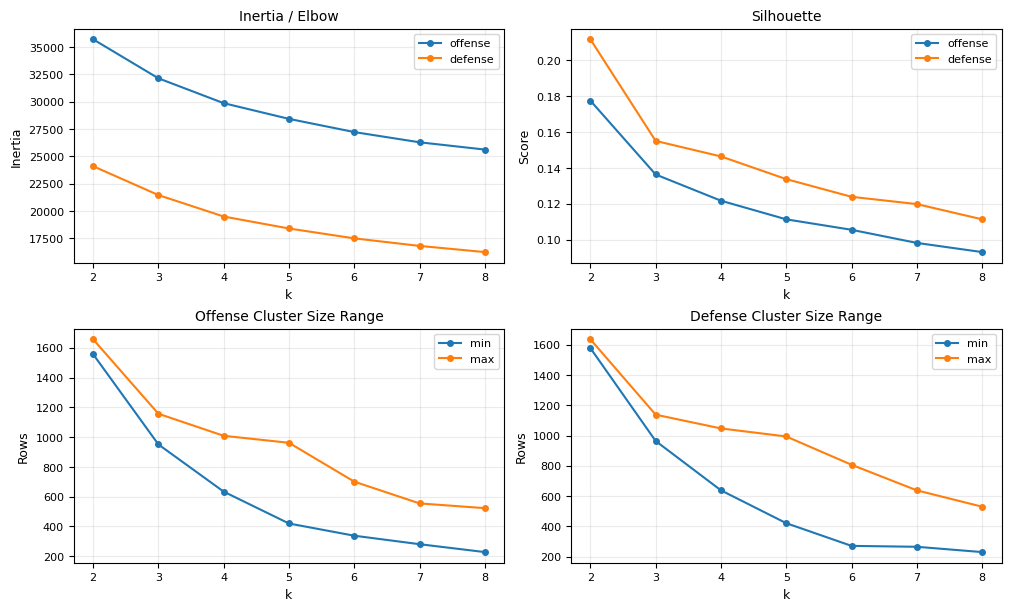

,model_type,k,inertia,silhouette,min_cluster_size,max_cluster_size
0,defense,2,24095.3625,0.2116,1578,1636
1,defense,3,21452.4038,0.1550,964,1138
2,defense,4,19489.9435,0.1464,638,1047
3,defense,5,18393.8128,0.1337,421,994
4,defense,6,17490.7907,0.1239,271,807
5,defense,7,16800.6705,0.1198,265,638
6,defense,8,16234.9745,0.1113,230,530
7,offense,2,35705.7070,0.1775,1557,1657
8,offense,3,32136.9259,0.1363,951,1157
9,offense,4,29862.1217,0.1217,634,1009


Cell 5A complete.
This visual is diagnostic only. It does not select k.


In [19]:
# Cell 5A — Compact 2x2 visualization for k-means diagnostics
# No k is selected here. This is only for visual inspection.

import matplotlib.pyplot as plt

k_plot_df = k_eval.copy().sort_values(["model_type", "k"])

fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)

# -------------------------------------------------------------------
# 1. Inertia / elbow
# -------------------------------------------------------------------

ax = axes[0, 0]

for model_type in ["offense", "defense"]:
    d = k_plot_df[k_plot_df["model_type"] == model_type]
    ax.plot(d["k"], d["inertia"], marker="o", linewidth=1.5, markersize=4, label=model_type)

ax.set_title("Inertia / Elbow", fontsize=10)
ax.set_xlabel("k", fontsize=9)
ax.set_ylabel("Inertia", fontsize=9)
ax.set_xticks(sorted(k_plot_df["k"].unique()))
ax.tick_params(labelsize=8)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

# -------------------------------------------------------------------
# 2. Silhouette score
# -------------------------------------------------------------------

ax = axes[0, 1]

for model_type in ["offense", "defense"]:
    d = k_plot_df[k_plot_df["model_type"] == model_type]
    ax.plot(d["k"], d["silhouette"], marker="o", linewidth=1.5, markersize=4, label=model_type)

ax.set_title("Silhouette", fontsize=10)
ax.set_xlabel("k", fontsize=9)
ax.set_ylabel("Score", fontsize=9)
ax.set_xticks(sorted(k_plot_df["k"].unique()))
ax.tick_params(labelsize=8)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

# -------------------------------------------------------------------
# 3. Offense cluster size range
# -------------------------------------------------------------------

ax = axes[1, 0]

d = k_plot_df[k_plot_df["model_type"] == "offense"]
ax.plot(d["k"], d["min_cluster_size"], marker="o", linewidth=1.5, markersize=4, label="min")
ax.plot(d["k"], d["max_cluster_size"], marker="o", linewidth=1.5, markersize=4, label="max")

ax.set_title("Offense Cluster Size Range", fontsize=10)
ax.set_xlabel("k", fontsize=9)
ax.set_ylabel("Rows", fontsize=9)
ax.set_xticks(sorted(d["k"].unique()))
ax.tick_params(labelsize=8)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

# -------------------------------------------------------------------
# 4. Defense cluster size range
# -------------------------------------------------------------------

ax = axes[1, 1]

d = k_plot_df[k_plot_df["model_type"] == "defense"]
ax.plot(d["k"], d["min_cluster_size"], marker="o", linewidth=1.5, markersize=4, label="min")
ax.plot(d["k"], d["max_cluster_size"], marker="o", linewidth=1.5, markersize=4, label="max")

ax.set_title("Defense Cluster Size Range", fontsize=10)
ax.set_xlabel("k", fontsize=9)
ax.set_ylabel("Rows", fontsize=9)
ax.set_xticks(sorted(d["k"].unique()))
ax.tick_params(labelsize=8)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

plt.show()

display(
    k_plot_df
    .sort_values(["model_type", "k"])
    .reset_index(drop=True)
)

print("Cell 5A complete.")
print("This visual is diagnostic only. It does not select k.")

In [20]:
# Cell 6 — Profile offense and defense clusters for k=3, k=4, and k=5

PROFILE_K_VALUES = [3, 4, 5]

def fit_cluster_profile(df, feature_cols, model_dict, k, model_type):
    """
    Assign clusters for a given k and return:
    - row-level cluster assignments
    - cluster profile table in raw feature units
    - standardized centroid table
    """
    model = model_dict[k]["model"]
    scaler = model_dict[k]["scaler"]
    cluster_id = model_dict[k]["cluster_id"]
    
    out = df.copy()
    out[f"{model_type}_cluster_k{k}"] = cluster_id
    
    profile = (
        out
        .groupby(f"{model_type}_cluster_k{k}", as_index=False)
        .agg(
            n=("game_id", "count"),
            teams=("team_name", "nunique"),
            games=("game_id", "nunique"),
            **{col: (col, "mean") for col in feature_cols}
        )
    )
    
    profile["cluster_share"] = profile["n"] / len(out)
    profile.insert(0, "model_type", model_type)
    profile.insert(1, "k", k)
    
    centroid_scaled = pd.DataFrame(
        model.cluster_centers_,
        columns=feature_cols,
    )
    centroid_scaled.insert(0, f"{model_type}_cluster_k{k}", range(k))
    centroid_scaled.insert(0, "k", k)
    centroid_scaled.insert(0, "model_type", model_type)
    
    return out, profile, centroid_scaled


offense_cluster_assignments = offense_cluster_matrix.copy()
defense_cluster_assignments = defense_cluster_matrix.copy()

offense_profiles = []
defense_profiles = []
offense_centroids_scaled = []
defense_centroids_scaled = []

for k in PROFILE_K_VALUES:
    off_assign, off_profile, off_centroid = fit_cluster_profile(
        df=offense_cluster_matrix,
        feature_cols=offense_style_features,
        model_dict=offense_k_models,
        k=k,
        model_type="offense",
    )
    
    def_assign, def_profile, def_centroid = fit_cluster_profile(
        df=defense_cluster_matrix,
        feature_cols=defense_style_features,
        model_dict=defense_k_models,
        k=k,
        model_type="defense",
    )
    
    offense_cluster_assignments[f"offense_cluster_k{k}"] = off_assign[f"offense_cluster_k{k}"]
    defense_cluster_assignments[f"defense_cluster_k{k}"] = def_assign[f"defense_cluster_k{k}"]
    
    offense_profiles.append(off_profile)
    defense_profiles.append(def_profile)
    offense_centroids_scaled.append(off_centroid)
    defense_centroids_scaled.append(def_centroid)

offense_cluster_profiles = pd.concat(offense_profiles, ignore_index=True)
defense_cluster_profiles = pd.concat(defense_profiles, ignore_index=True)
offense_cluster_centroids_scaled = pd.concat(offense_centroids_scaled, ignore_index=True)
defense_cluster_centroids_scaled = pd.concat(defense_centroids_scaled, ignore_index=True)

print("Offense cluster profile rows:", len(offense_cluster_profiles))
print("Defense cluster profile rows:", len(defense_cluster_profiles))

print("\nOffense cluster sizes:")
display(
    offense_cluster_profiles[
        ["model_type", "k", "offense_cluster_k3" if False else "n", "cluster_share"]
    ]
)

print("\nOffense profiles — k=3:")
display(
    offense_cluster_profiles[offense_cluster_profiles["k"] == 3]
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

print("\nOffense profiles — k=4:")
display(
    offense_cluster_profiles[offense_cluster_profiles["k"] == 4]
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

print("\nOffense profiles — k=5:")
display(
    offense_cluster_profiles[offense_cluster_profiles["k"] == 5]
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

print("\nDefense profiles — k=3:")
display(
    defense_cluster_profiles[defense_cluster_profiles["k"] == 3]
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

print("\nDefense profiles — k=4:")
display(
    defense_cluster_profiles[defense_cluster_profiles["k"] == 4]
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

print("\nDefense profiles — k=5:")
display(
    defense_cluster_profiles[defense_cluster_profiles["k"] == 5]
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

print("\nOffense standardized centroids:")
display(offense_cluster_centroids_scaled)

print("\nDefense standardized centroids:")
display(defense_cluster_centroids_scaled)

print("\nCell 6 complete.")
print("Next: inspect profiles and choose working k values for outcome validation.")

Offense cluster profile rows: 12
Defense cluster profile rows: 12

Offense cluster sizes:


,model_type,k,n,cluster_share
0,offense,3,1106,0.3441
1,offense,3,1157,0.3600
2,offense,3,951,0.2959
3,offense,4,778,0.2421
4,offense,4,634,0.1973
5,offense,4,793,0.2467
6,offense,4,1009,0.3139
7,offense,5,569,0.1770
8,offense,5,581,0.1808
9,offense,5,682,0.2122



Offense profiles — k=3:


,model_type,k,offense_cluster_k3,n,teams,games,off_epa_pass,off_epa_rush,off_explosive_rate_10,off_explosive_rate_20,off_line_yards_per_rush,off_pts_per_opportunity,off_sack_rate_allowed,off_stuff_rate,off_success_rate_pass,off_success_rate_pass_downs,off_success_rate_rush,off_success_rate_std_downs,rush_rate_pass_downs,rush_rate_std_downs,cluster_share,offense_cluster_k4,offense_cluster_k5
0,offense,3,1.0000,1157,130,928,0.5352,0.2589,0.2523,0.0917,2.7315,3.7881,0.0385,0.1478,0.5165,0.3813,0.4920,0.5387,0.3661,0.5821,0.3600,NaN,NaN
1,offense,3,0.0000,1106,131,899,0.1028,0.2077,0.1801,0.0555,2.7709,2.6390,0.0765,0.1244,0.3567,0.2527,0.4586,0.4681,0.3579,0.5851,0.3441,NaN,NaN
2,offense,3,2.0000,951,128,801,0.1951,-0.0507,0.1858,0.0616,2.2477,2.1660,0.0716,0.2478,0.3738,0.2573,0.3150,0.3898,0.2948,0.5204,0.2959,NaN,NaN



Offense profiles — k=4:


...


Offense standardized centroids:


,model_type,k,offense_cluster_k3,off_epa_pass,off_epa_rush,off_explosive_rate_10,off_explosive_rate_20,off_line_yards_per_rush,off_pts_per_opportunity,off_sack_rate_allowed,off_stuff_rate,off_success_rate_pass,off_success_rate_pass_downs,off_success_rate_rush,off_success_rate_std_downs,rush_rate_pass_downs,rush_rate_std_downs,offense_cluster_k4,offense_cluster_k5
0,offense,3,0.0000,-0.5744,0.2789,-0.4874,-0.4228,0.4884,-0.1706,0.2776,-0.5180,-0.5494,-0.3855,0.2709,-0.0257,0.0982,0.1541,NaN,NaN
1,offense,3,1.0000,0.7785,0.5264,0.7781,0.6065,0.3763,0.5405,-0.4158,-0.2501,0.8493,0.6520,0.5668,0.7448,0.1525,0.1323,NaN,NaN
2,offense,3,2.0000,-0.2816,-0.9667,-0.3823,-0.2481,-1.0273,-0.4609,0.1844,0.9077,-0.3971,-0.3469,-1.0066,-0.8788,-0.3003,-0.3407,NaN,NaN
3,offense,4,NaN,0.7115,0.9526,0.8450,0.6304,0.8323,0.6086,-0.3550,-0.5913,0.8140,0.6081,0.9636,1.0305,0.2815,0.2872,0.0000,NaN
4,offense,4,NaN,-0.6540,-1.0923,-0.7371,-0.5383,-1.0506,-0.7384,0.4787,0.8928,-0.8069,-0.6765,-1.1556,-1.1400,-0.2408,-0.2576,1.0000,NaN
5,offense,4,NaN,0.5485,-0.3947,0.4082,0.3852,-0.5990,0.2405,-0.2903,0.5373,0.5299,0.4522,-0.3480,-0.0574,-0.1647,-0.2370,2.0000,NaN
6,offense,4,NaN,-0.5688,0.2620,-0.5092,-0.4506,0.4892,-0.1943,0.2011,-0.5274,-0.5371,-0.3992,0.2566,-0.0332,0.0636,0.1266,3.0000,NaN
7,offense,5,NaN,-0.2569,-1.1898,-0.3221,-0.2603,-1.2322,-0.4835,0.0518,1.0913,-0.3629,-0.3450,-1.1380,-0.9014,-0.5357,-0.5870,NaN,0.0000
8,offense,5,NaN,0.7178,1.1139,0.9369,0.7222,0.9670,0.6789,-0.3388,-0.6747,0.8332,0.6399,1.1235,1.1760,0.3617,0.3339,NaN,1.0000
9,offense,5,NaN,0.7938,-0.1903,0.5261,0.5202,-0.4227,0.3829,-0.4017,0.4284,0.7660,0.6013,-0.1877,0.1374,0.1038,0.0305,NaN,2.0000



Defense standardized centroids:


,model_type,k,defense_cluster_k3,def_epa_pass_allowed,def_epa_rush_allowed,def_explosive_rate_10_allowed,def_explosive_rate_20_allowed,def_pts_per_opportunity_allowed,def_sack_rate,def_stuff_rate_allowed,def_success_rate_pass_allowed,def_success_rate_rush_allowed,def_success_rate_std_downs_allowed,defense_cluster_k4,defense_cluster_k5
0,defense,3,0.0000,-0.3906,-0.9472,-0.5113,-0.3545,-0.5516,0.2992,0.7743,-0.5408,-1.0326,-0.9721,NaN,NaN
1,defense,3,1.0000,-0.4949,0.3590,-0.3865,-0.4000,-0.0441,0.1560,-0.5191,-0.4045,0.4090,0.1030,NaN,NaN
2,defense,3,2.0000,0.8450,0.4537,0.8388,0.7166,0.5233,-0.4190,-0.1401,0.8828,0.4765,0.7374,NaN,NaN
3,defense,4,NaN,-0.4031,0.4365,-0.2795,-0.3271,0.0328,0.0729,-0.5514,-0.3021,0.5017,0.2084,0.0000,NaN
4,defense,4,NaN,0.9149,0.7938,1.0174,0.8323,0.6208,-0.4475,-0.3864,0.9940,0.7982,1.0227,1.0000,NaN
5,defense,4,NaN,-0.9193,-0.7645,-0.9380,-0.7105,-0.8413,0.7069,0.4414,-1.0709,-0.9091,-1.1577,2.0000,NaN
6,defense,4,NaN,0.4158,-0.7190,0.1677,0.2226,0.0494,-0.2469,0.7473,0.3286,-0.6925,-0.3114,3.0000,NaN
7,defense,5,NaN,0.7501,-0.3544,0.5098,0.5388,0.2830,-0.3292,0.4438,0.6502,-0.3754,0.0174,NaN,0.0000
8,defense,5,NaN,-0.3057,0.4115,-0.2423,-0.3125,0.0937,-0.0491,-0.5244,-0.1885,0.5181,0.2786,NaN,1.0000
9,defense,5,NaN,-1.1970,-0.1950,-1.0353,-0.7527,-0.7651,1.2564,-0.1132,-1.3200,-0.4198,-0.8878,NaN,2.0000



Cell 6 complete.
Next: inspect profiles and choose working k values for outcome validation.


Cluster 0: high-efficiency balanced offense
- strong pass EPA
- strong rush EPA
- strong success rates
- high points per opportunity

Cluster 1: struggling / low-efficiency offense
- weak pass EPA
- weak rush EPA
- poor success rates
- low points per opportunity
- higher sack rate allowed

Cluster 2: pass-leaning efficient offense
- strong pass EPA and pass success
- weaker rush profile
- good explosiveness

Cluster 3: run-leaning / lower-pass-efficiency offense
- decent rush profile
- weaker pass profile
- lower explosiveness / points per opportunity

Cluster 0: vulnerable rush / moderate pass defense
- higher rush EPA allowed
- weaker rush success allowed
- moderate pass profile

Cluster 1: struggling defense
- high pass EPA allowed
- high rush EPA allowed
- high explosiveness allowed
- high points per opportunity allowed

Cluster 2: strong defense
- low pass EPA allowed
- low rush EPA allowed
- low explosiveness allowed
- high sack rate
- low success allowed

Cluster 3: pass-vulnerable / run-stopper defense
- higher pass EPA allowed
- lower rush EPA allowed
- high stuff rate

In [21]:
# Cell 7 — Lock working k=4 archetype assignments and create neutral labels

# Based on k diagnostics and profile inspection:
# - k=2 is too coarse
# - k=3 is interpretable but under-specified
# - k=5 fragments into narrower subtypes without enough added clarity
# - k=4 is the working structure for outcome validation

WORKING_OFFENSE_K = 4
WORKING_DEFENSE_K = 4

offense_cluster_col = f"offense_cluster_k{WORKING_OFFENSE_K}"
defense_cluster_col = f"defense_cluster_k{WORKING_DEFENSE_K}"

# Neutral labels first. Descriptive labels are added only after profile inspection.
offense_cluster_assignments["off_archetype_id"] = offense_cluster_assignments[offense_cluster_col]
defense_cluster_assignments["def_archetype_id"] = defense_cluster_assignments[defense_cluster_col]

# Descriptive labels from Cell 6 profile inspection.
# These labels are for interpretation only and still require outcome validation.

offense_archetype_label_map = {
    0: "high_efficiency_balanced",
    1: "low_efficiency_struggling",
    2: "pass_leaning_efficient",
    3: "run_leaning_limited_pass",
}

defense_archetype_label_map = {
    0: "rush_vulnerable_moderate_pass",
    1: "struggling_all_phase",
    2: "strong_all_phase",
    3: "pass_vulnerable_run_stopper",
}

offense_cluster_assignments["off_archetype_label"] = (
    offense_cluster_assignments["off_archetype_id"]
    .map(offense_archetype_label_map)
)

defense_cluster_assignments["def_archetype_label"] = (
    defense_cluster_assignments["def_archetype_id"]
    .map(defense_archetype_label_map)
)

print("Working offense k:", WORKING_OFFENSE_K)
print("Working defense k:", WORKING_DEFENSE_K)

print("\nOffense archetype counts:")
print(
    offense_cluster_assignments["off_archetype_label"]
    .value_counts()
    .to_string()
)

print("\nDefense archetype counts:")
print(
    defense_cluster_assignments["def_archetype_label"]
    .value_counts()
    .to_string()
)

# -------------------------------------------------------------------
# Merge offense and defense archetypes to one team-game archetype table
# -------------------------------------------------------------------

team_game_archetypes = offense_cluster_assignments[
    [
        "game_id",
        "season",
        "week",
        "team_name",
        "opponent",
        "conference",
        "tier",
        "off_archetype_id",
        "off_archetype_label",
    ]
].merge(
    defense_cluster_assignments[
        [
            "game_id",
            "team_name",
            "def_archetype_id",
            "def_archetype_label",
        ]
    ],
    on=["game_id", "team_name"],
    how="inner",
)

print("\nTeam-game archetype rows:", len(team_game_archetypes))
print("Unique games:", team_game_archetypes["game_id"].nunique())

print("\nRows by season:")
print(team_game_archetypes["season"].value_counts().sort_index().to_string())

print("\nOffense x defense archetype cross-tab:")
display(
    pd.crosstab(
        team_game_archetypes["off_archetype_label"],
        team_game_archetypes["def_archetype_label"],
    )
)

assert len(team_game_archetypes) == len(team_game_matrix), "ERROR: Archetype merge changed row count."
assert team_game_archetypes["off_archetype_label"].isna().sum() == 0, "ERROR: Null offense labels."
assert team_game_archetypes["def_archetype_label"].isna().sum() == 0, "ERROR: Null defense labels."
assert HOLDOUT_SEASON not in team_game_archetypes["season"].unique(), "ERROR: 2025 leaked into archetypes."

print("\nCell 7 complete.")
print("Working k=4 archetypes assigned. Next: build game-level matchup features.")

Working offense k: 4
Working defense k: 4

Offense archetype counts:
off_archetype_label
run_leaning_limited_pass     1009
pass_leaning_efficient        793
high_efficiency_balanced      778
low_efficiency_struggling     634

Defense archetype counts:
def_archetype_label
rush_vulnerable_moderate_pass    1047
pass_vulnerable_run_stopper       782
struggling_all_phase              747
strong_all_phase                  638

Team-game archetype rows: 3214
Unique games: 1607

Rows by season:
season
2022    1046
2023    1092
2024    1076

Offense x defense archetype cross-tab:


def_archetype_label,pass_vulnerable_run_stopper,rush_vulnerable_moderate_pass,strong_all_phase,struggling_all_phase
off_archetype_label,,,,
high_efficiency_balanced,157,260,146,215
low_efficiency_struggling,163,182,160,129
pass_leaning_efficient,211,256,143,183
run_leaning_limited_pass,251,349,189,220



Cell 7 complete.
Working k=4 archetypes assigned. Next: build game-level matchup features.


In [25]:
# Cell 7B — Spot check CFP teams and known sanity-check teams for archetype validity

# These are not final validation tests by themselves.
# They are sanity checks to catch obviously bad labels before outcome testing.
#
# Minimum requirement:
# - Every CFP team in the 2022–2024 development window should appear here.
# - Notre Dame 2024 may be missing under the current FBS conference-game-only filter.
#   That is expected if no valid conference-game rows exist for Notre Dame.

spot_check_teams = [
    # -------------------------------------------------------------------
    # 2022 CFP
    # -------------------------------------------------------------------
    ("Georgia", 2022),
    ("TCU", 2022),
    ("Michigan", 2022),
    ("Ohio State", 2022),

    # -------------------------------------------------------------------
    # 2023 CFP
    # -------------------------------------------------------------------
    ("Michigan", 2023),
    ("Washington", 2023),
    ("Texas", 2023),
    ("Alabama", 2023),

    # -------------------------------------------------------------------
    # 2024 CFP — 12-team playoff
    # -------------------------------------------------------------------
    ("Oregon", 2024),
    ("Georgia", 2024),
    ("Boise State", 2024),
    ("Arizona State", 2024),
    ("Texas", 2024),
    ("Penn State", 2024),
    ("Notre Dame", 2024),
    ("Ohio State", 2024),
    ("Tennessee", 2024),
    ("Indiana", 2024),
    ("SMU", 2024),
    ("Clemson", 2024),

    # -------------------------------------------------------------------
    # Additional sanity checks / contrast teams
    # -------------------------------------------------------------------
    ("Iowa", 2023),
    ("USC", 2023),
    ("Colorado", 2023),
    ("LSU", 2023),
    ("Florida State", 2023),
    ("Kent State", 2023),
]

spot_check_df = pd.DataFrame(
    spot_check_teams,
    columns=["team_name", "season"]
).drop_duplicates()

# -------------------------------------------------------------------
# Team-season archetype summary
# -------------------------------------------------------------------
# Because archetypes are assigned at team-game grain, summarize each team-season
# using the modal archetype and the share of games in that modal archetype.

team_season_archetype_summary = (
    team_game_archetypes
    .groupby(["team_name", "season", "conference", "tier"], as_index=False)
    .agg(
        games=("game_id", "nunique"),
        off_archetype_mode=("off_archetype_label", lambda x: x.value_counts().idxmax()),
        off_archetype_mode_share=("off_archetype_label", lambda x: x.value_counts(normalize=True).max()),
        def_archetype_mode=("def_archetype_label", lambda x: x.value_counts().idxmax()),
        def_archetype_mode_share=("def_archetype_label", lambda x: x.value_counts(normalize=True).max()),
    )
)

# Add full archetype counts by team-season for auditability.
off_counts = (
    team_game_archetypes
    .groupby(["team_name", "season", "off_archetype_label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

off_counts = off_counts.rename(
    columns={
        col: f"off_count__{col}"
        for col in off_counts.columns
        if col not in ["team_name", "season"]
    }
)

def_counts = (
    team_game_archetypes
    .groupby(["team_name", "season", "def_archetype_label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

def_counts = def_counts.rename(
    columns={
        col: f"def_count__{col}"
        for col in def_counts.columns
        if col not in ["team_name", "season"]
    }
)

team_season_archetype_summary = (
    team_season_archetype_summary
    .merge(off_counts, on=["team_name", "season"], how="left")
    .merge(def_counts, on=["team_name", "season"], how="left")
)

# -------------------------------------------------------------------
# Team-season style summary
# -------------------------------------------------------------------

team_season_style_summary = (
    team_game_matrix
    .groupby(["team_name", "season"], as_index=False)[offense_style_features + defense_style_features]
    .mean()
)

team_season_spot = (
    spot_check_df
    .merge(
        team_season_archetype_summary,
        on=["team_name", "season"],
        how="left",
    )
    .merge(
        team_season_style_summary,
        on=["team_name", "season"],
        how="left",
    )
)

print("Spot check rows requested:", len(spot_check_df))
print("Spot check teams found:", team_season_spot["games"].notna().sum())
print("Spot check teams missing:", team_season_spot["games"].isna().sum())

if team_season_spot["games"].isna().sum() > 0:
    print("\nMissing spot check rows:")
    display(
        team_season_spot[
            team_season_spot["games"].isna()
        ][["team_name", "season"]]
        .sort_values(["season", "team_name"])
        .reset_index(drop=True)
    )

# -------------------------------------------------------------------
# CFP coverage check
# -------------------------------------------------------------------

expected_playoff_checks = pd.DataFrame(
    [
        # 2022 CFP
        ("Georgia", 2022, "CFP_2022"),
        ("TCU", 2022, "CFP_2022"),
        ("Michigan", 2022, "CFP_2022"),
        ("Ohio State", 2022, "CFP_2022"),

        # 2023 CFP
        ("Michigan", 2023, "CFP_2023"),
        ("Washington", 2023, "CFP_2023"),
        ("Texas", 2023, "CFP_2023"),
        ("Alabama", 2023, "CFP_2023"),

        # 2024 CFP
        ("Oregon", 2024, "CFP_2024"),
        ("Georgia", 2024, "CFP_2024"),
        ("Boise State", 2024, "CFP_2024"),
        ("Arizona State", 2024, "CFP_2024"),
        ("Texas", 2024, "CFP_2024"),
        ("Penn State", 2024, "CFP_2024"),
        ("Notre Dame", 2024, "CFP_2024"),
        ("Ohio State", 2024, "CFP_2024"),
        ("Tennessee", 2024, "CFP_2024"),
        ("Indiana", 2024, "CFP_2024"),
        ("SMU", 2024, "CFP_2024"),
        ("Clemson", 2024, "CFP_2024"),
    ],
    columns=["team_name", "season", "playoff_group"]
)

playoff_coverage_check = expected_playoff_checks.merge(
    team_season_archetype_summary[
        [
            "team_name",
            "season",
            "conference",
            "tier",
            "games",
            "off_archetype_mode",
            "off_archetype_mode_share",
            "def_archetype_mode",
            "def_archetype_mode_share",
        ]
    ],
    on=["team_name", "season"],
    how="left",
)

print("\nPlayoff team coverage check:")
display(
    playoff_coverage_check
    .sort_values(["season", "team_name"])
    .reset_index(drop=True)
)

missing_playoff_teams = playoff_coverage_check[
    playoff_coverage_check["games"].isna()
].copy()

print("\nMissing playoff teams:")
display(
    missing_playoff_teams
    .sort_values(["season", "team_name"])
    .reset_index(drop=True)
)

allowed_missing = {
    ("Notre Dame", 2024),
}

unexpected_missing = missing_playoff_teams[
    ~missing_playoff_teams.apply(
        lambda row: (row["team_name"], row["season"]) in allowed_missing,
        axis=1,
    )
].copy()

assert len(unexpected_missing) == 0, (
    "ERROR: Unexpected CFP teams missing from spot check coverage."
)

# -------------------------------------------------------------------
# Display spot-check summary table
# -------------------------------------------------------------------

summary_cols = [
    "team_name",
    "season",
    "conference",
    "tier",
    "games",
    "off_archetype_mode",
    "off_archetype_mode_share",
    "def_archetype_mode",
    "def_archetype_mode_share",

    # Offense metrics
    "off_epa_pass",
    "off_epa_rush",
    "off_success_rate_pass",
    "off_success_rate_pass_downs",
    "off_success_rate_rush",
    "off_success_rate_std_downs",
    "rush_rate_pass_downs",
    "rush_rate_std_downs",
    "off_sack_rate_allowed",
    "off_pts_per_opportunity",

    # Defense metrics
    "def_epa_pass_allowed",
    "def_epa_rush_allowed",
    "def_success_rate_pass_allowed",
    "def_success_rate_rush_allowed",
    "def_success_rate_std_downs_allowed",
    "def_sack_rate",
    "def_pts_per_opportunity_allowed",
]

print("\nSpot check archetype summary:")
display(
    team_season_spot[summary_cols]
    .sort_values(["season", "team_name"])
    .reset_index(drop=True)
)

# -------------------------------------------------------------------
# Full archetype distribution for each spot-check team-season
# -------------------------------------------------------------------

spot_check_distribution = (
    team_game_archetypes
    .merge(spot_check_df, on=["team_name", "season"], how="inner")
    .groupby(
        [
            "team_name",
            "season",
            "off_archetype_label",
            "def_archetype_label",
        ],
        as_index=False,
    )
    .agg(games=("game_id", "nunique"))
    .sort_values(["season", "team_name", "games"], ascending=[True, True, False])
)

print("\nSpot check full archetype distribution:")
display(spot_check_distribution.reset_index(drop=True))

# -------------------------------------------------------------------
# CFP-only compact view
# -------------------------------------------------------------------

cfp_compact = (
    playoff_coverage_check
    .merge(
        team_season_style_summary,
        on=["team_name", "season"],
        how="left",
    )
)

print("\nCFP compact sanity view:")
display(
    cfp_compact[
        [
            "playoff_group",
            "team_name",
            "season",
            "conference",
            "tier",
            "games",
            "off_archetype_mode",
            "off_archetype_mode_share",
            "def_archetype_mode",
            "def_archetype_mode_share",
            "off_epa_pass",
            "off_epa_rush",
            "off_success_rate_pass",
            "off_success_rate_rush",
            "def_epa_pass_allowed",
            "def_epa_rush_allowed",
            "def_success_rate_pass_allowed",
            "def_success_rate_rush_allowed",
            "def_sack_rate",
        ]
    ]
    .sort_values(["season", "team_name"])
    .reset_index(drop=True)
)

# -------------------------------------------------------------------
# Hard sanity checks
# -------------------------------------------------------------------
# These are intentionally conservative. They catch obvious label failure.
# They are not meant to encode full football truth.

hard_checks = []

def get_spot_row(team, season):
    d = team_season_spot[
        (team_season_spot["team_name"] == team)
        & (team_season_spot["season"] == season)
    ]
    if len(d) == 0:
        return None
    return d.iloc[0]

def append_check(check_name, observed, passes):
    hard_checks.append({
        "check": check_name,
        "observed": observed,
        "passes": bool(passes),
    })

# Michigan 2023 should not be labeled as a struggling all-phase defense.
row = get_spot_row("Michigan", 2023)
if row is not None and pd.notna(row["def_archetype_mode"]):
    append_check(
        "Michigan 2023 defense should not be struggling_all_phase",
        row["def_archetype_mode"],
        row["def_archetype_mode"] != "struggling_all_phase",
    )

# Georgia 2022 should not be labeled as a struggling all-phase defense.
row = get_spot_row("Georgia", 2022)
if row is not None and pd.notna(row["def_archetype_mode"]):
    append_check(
        "Georgia 2022 defense should not be struggling_all_phase",
        row["def_archetype_mode"],
        row["def_archetype_mode"] != "struggling_all_phase",
    )

# Washington 2023 should not be labeled as a low-efficiency offense.
row = get_spot_row("Washington", 2023)
if row is not None and pd.notna(row["off_archetype_mode"]):
    append_check(
        "Washington 2023 offense should not be low_efficiency_struggling",
        row["off_archetype_mode"],
        row["off_archetype_mode"] != "low_efficiency_struggling",
    )

# LSU 2023 should not be labeled as a low-efficiency offense.
row = get_spot_row("LSU", 2023)
if row is not None and pd.notna(row["off_archetype_mode"]):
    append_check(
        "LSU 2023 offense should not be low_efficiency_struggling",
        row["off_archetype_mode"],
        row["off_archetype_mode"] != "low_efficiency_struggling",
    )

# Iowa 2023 offense should not be labeled high-efficiency balanced.
row = get_spot_row("Iowa", 2023)
if row is not None and pd.notna(row["off_archetype_mode"]):
    append_check(
        "Iowa 2023 offense should not be high_efficiency_balanced",
        row["off_archetype_mode"],
        row["off_archetype_mode"] != "high_efficiency_balanced",
    )

# Kent State 2023 should not be labeled high-efficiency balanced.
row = get_spot_row("Kent State", 2023)
if row is not None and pd.notna(row["off_archetype_mode"]):
    append_check(
        "Kent State 2023 offense should not be high_efficiency_balanced",
        row["off_archetype_mode"],
        row["off_archetype_mode"] != "high_efficiency_balanced",
    )

# USC 2023 defense should not be labeled strong_all_phase.
row = get_spot_row("USC", 2023)
if row is not None and pd.notna(row["def_archetype_mode"]):
    append_check(
        "USC 2023 defense should not be strong_all_phase",
        row["def_archetype_mode"],
        row["def_archetype_mode"] != "strong_all_phase",
    )

# 2024 Ohio State should not be labeled low-efficiency offense.
row = get_spot_row("Ohio State", 2024)
if row is not None and pd.notna(row["off_archetype_mode"]):
    append_check(
        "Ohio State 2024 offense should not be low_efficiency_struggling",
        row["off_archetype_mode"],
        row["off_archetype_mode"] != "low_efficiency_struggling",
    )

# 2024 Oregon should not be labeled low-efficiency offense.
row = get_spot_row("Oregon", 2024)
if row is not None and pd.notna(row["off_archetype_mode"]):
    append_check(
        "Oregon 2024 offense should not be low_efficiency_struggling",
        row["off_archetype_mode"],
        row["off_archetype_mode"] != "low_efficiency_struggling",
    )

hard_checks_df = pd.DataFrame(hard_checks)

print("\nHard sanity checks:")
display(hard_checks_df)

assert len(hard_checks_df) > 0, "ERROR: No hard sanity checks were created."
assert hard_checks_df["passes"].all(), "ERROR: One or more archetype spot checks failed."

# -------------------------------------------------------------------
# Final notes
# -------------------------------------------------------------------

print("\nCell 7B complete.")
print("Spot checks passed.")
print(
    "Note: Passing spot checks does not prove predictive validity. "
    "It only confirms labels are not obviously broken before outcome validation."
)

Spot check rows requested: 26
Spot check teams found: 25
Spot check teams missing: 1

Missing spot check rows:


,team_name,season
0,Notre Dame,2024



Playoff team coverage check:


,team_name,season,playoff_group,conference,tier,games,off_archetype_mode,off_archetype_mode_share,def_archetype_mode,def_archetype_mode_share
0,Georgia,2022,CFP_2022,SEC,P4,9.0000,high_efficiency_balanced,0.5556,strong_all_phase,0.8889
1,Michigan,2022,CFP_2022,Big Ten,P4,10.0000,high_efficiency_balanced,0.6000,strong_all_phase,0.5000
2,Ohio State,2022,CFP_2022,Big Ten,P4,9.0000,high_efficiency_balanced,0.4444,strong_all_phase,0.5556
3,TCU,2022,CFP_2022,Big 12,P4,10.0000,run_leaning_limited_pass,0.4000,rush_vulnerable_moderate_pass,0.6000
4,Alabama,2023,CFP_2023,SEC,P4,9.0000,high_efficiency_balanced,0.4444,strong_all_phase,0.3333
5,Michigan,2023,CFP_2023,Big Ten,P4,10.0000,high_efficiency_balanced,0.4000,strong_all_phase,0.7000
6,Texas,2023,CFP_2023,Big 12,P4,10.0000,pass_leaning_efficient,0.5000,rush_vulnerable_moderate_pass,0.4000
7,Washington,2023,CFP_2023,Pac-12,G5,10.0000,high_efficiency_balanced,0.4000,rush_vulnerable_moderate_pass,0.7000
8,Arizona State,2024,CFP_2024,Big 12,P4,10.0000,high_efficiency_balanced,0.5000,pass_vulnerable_run_stopper,0.3000
9,Boise State,2024,CFP_2024,Mountain West,G5,8.0000,high_efficiency_balanced,0.5000,pass_vulnerable_run_stopper,0.3750



Missing playoff teams:


...


CFP compact sanity view:


,playoff_group,team_name,season,conference,tier,games,off_archetype_mode,off_archetype_mode_share,def_archetype_mode,def_archetype_mode_share,off_epa_pass,off_epa_rush,off_success_rate_pass,off_success_rate_rush,def_epa_pass_allowed,def_epa_rush_allowed,def_success_rate_pass_allowed,def_success_rate_rush_allowed,def_sack_rate
0,CFP_2022,Georgia,2022,SEC,P4,9.0000,high_efficiency_balanced,0.5556,strong_all_phase,0.8889,0.4925,0.2431,0.5444,0.5072,0.0321,-0.0720,0.3277,0.3223,0.0476
1,CFP_2022,Michigan,2022,Big Ten,P4,10.0000,high_efficiency_balanced,0.6000,strong_all_phase,0.5000,0.3644,0.2737,0.4654,0.5035,0.1144,0.0106,0.3831,0.3508,0.0729
2,CFP_2022,Ohio State,2022,Big Ten,P4,9.0000,high_efficiency_balanced,0.4444,strong_all_phase,0.5556,0.4918,0.2256,0.5191,0.4749,0.0983,0.0270,0.3284,0.3400,0.0821
3,CFP_2022,TCU,2022,Big 12,P4,10.0000,run_leaning_limited_pass,0.4000,rush_vulnerable_moderate_pass,0.6000,0.3479,0.1610,0.3986,0.4548,0.1693,0.1623,0.3686,0.4371,0.0573
4,CFP_2023,Alabama,2023,SEC,P4,9.0000,high_efficiency_balanced,0.4444,strong_all_phase,0.3333,0.5132,0.1446,0.4785,0.4212,0.1483,0.2344,0.3674,0.3997,0.1025
5,CFP_2023,Michigan,2023,Big Ten,P4,10.0000,high_efficiency_balanced,0.4000,strong_all_phase,0.7000,0.4509,0.1665,0.5559,0.4547,0.1740,-0.0065,0.3430,0.3364,0.0686
6,CFP_2023,Texas,2023,Big 12,P4,10.0000,pass_leaning_efficient,0.5000,rush_vulnerable_moderate_pass,0.4000,0.3592,0.2250,0.5089,0.4391,0.2194,-0.0788,0.3959,0.3222,0.0509
7,CFP_2023,Washington,2023,Pac-12,G5,10.0000,high_efficiency_balanced,0.4000,rush_vulnerable_moderate_pass,0.7000,0.4402,0.1717,0.5037,0.5000,0.2412,0.3294,0.4410,0.5387,0.0275
8,CFP_2024,Arizona State,2024,Big 12,P4,10.0000,high_efficiency_balanced,0.5000,pass_vulnerable_run_stopper,0.3000,0.4709,0.2225,0.4829,0.4904,0.2017,0.1234,0.4553,0.4210,0.0292
9,CFP_2024,Boise State,2024,Mountain West,G5,8.0000,high_efficiency_balanced,0.5000,pass_vulnerable_run_stopper,0.3750,0.4152,0.2350,0.4863,0.4633,0.2141,0.1124,0.3659,0.3562,0.1046



Hard sanity checks:


,check,observed,passes
0,Michigan 2023 defense should not be struggling...,strong_all_phase,True
1,Georgia 2022 defense should not be struggling_...,strong_all_phase,True
2,Washington 2023 offense should not be low_effi...,high_efficiency_balanced,True
3,LSU 2023 offense should not be low_efficiency_...,high_efficiency_balanced,True
4,Iowa 2023 offense should not be high_efficienc...,low_efficiency_struggling,True
5,Kent State 2023 offense should not be high_eff...,low_efficiency_struggling,True
6,USC 2023 defense should not be strong_all_phase,struggling_all_phase,True
7,Ohio State 2024 offense should not be low_effi...,high_efficiency_balanced,True
8,Oregon 2024 offense should not be low_efficien...,high_efficiency_balanced,True



Cell 7B complete.
Spot checks passed.
Note: Passing spot checks does not prove predictive validity. It only confirms labels are not obviously broken before outcome validation.


In [26]:
# Cell 8 — Build game-level archetype matchup table with outcomes and controls

# -------------------------------------------------------------------
# Split team-game archetypes into home and away rows
# -------------------------------------------------------------------

home_arch = team_game_archetypes.merge(
    valid_games[
        [
            "game_id",
            "season",
            "week",
            "home_team",
            "away_team",
            "home_conference",
            "away_conference",
            "home_points",
            "away_points",
            "point_differential",
            "total_points",
            "sp_rating_delta",
        ]
    ],
    on=["game_id", "season", "week"],
    how="inner",
)

home_arch = home_arch[home_arch["team_name"] == home_arch["home_team"]].copy()

away_arch = team_game_archetypes.merge(
    valid_games[
        [
            "game_id",
            "season",
            "week",
            "home_team",
            "away_team",
            "home_conference",
            "away_conference",
            "home_points",
            "away_points",
            "point_differential",
            "total_points",
            "sp_rating_delta",
        ]
    ],
    on=["game_id", "season", "week"],
    how="inner",
)

away_arch = away_arch[away_arch["team_name"] == away_arch["away_team"]].copy()

print("Home archetype rows:", len(home_arch))
print("Away archetype rows:", len(away_arch))

assert len(home_arch) == len(valid_games), "ERROR: Home archetype row count mismatch."
assert len(away_arch) == len(valid_games), "ERROR: Away archetype row count mismatch."

# -------------------------------------------------------------------
# Construct game-level archetype matchup table
# -------------------------------------------------------------------

home_arch_small = home_arch[
    [
        "game_id",
        "season",
        "week",
        "home_team",
        "away_team",
        "home_conference",
        "away_conference",
        "home_points",
        "away_points",
        "point_differential",
        "total_points",
        "sp_rating_delta",
        "off_archetype_id",
        "off_archetype_label",
        "def_archetype_id",
        "def_archetype_label",
    ]
].rename(
    columns={
        "off_archetype_id": "home_off_archetype_id",
        "off_archetype_label": "home_off_archetype_label",
        "def_archetype_id": "home_def_archetype_id",
        "def_archetype_label": "home_def_archetype_label",
    }
)

away_arch_small = away_arch[
    [
        "game_id",
        "off_archetype_id",
        "off_archetype_label",
        "def_archetype_id",
        "def_archetype_label",
    ]
].rename(
    columns={
        "off_archetype_id": "away_off_archetype_id",
        "off_archetype_label": "away_off_archetype_label",
        "def_archetype_id": "away_def_archetype_id",
        "def_archetype_label": "away_def_archetype_label",
    }
)

game_archetypes = home_arch_small.merge(
    away_arch_small,
    on="game_id",
    how="inner",
)

# Home conference is enough for stratification because these are conference games.
game_archetypes["conference"] = game_archetypes["home_conference"]
game_archetypes["team_name"] = game_archetypes["home_team"]
game_archetypes["tier"] = game_archetypes.apply(assign_tier, axis=1)

# -------------------------------------------------------------------
# Matchup labels
# -------------------------------------------------------------------

game_archetypes["home_off_vs_away_def_matchup"] = (
    game_archetypes["home_off_archetype_label"]
    + "_vs_"
    + game_archetypes["away_def_archetype_label"]
)

game_archetypes["away_off_vs_home_def_matchup"] = (
    game_archetypes["away_off_archetype_label"]
    + "_vs_"
    + game_archetypes["home_def_archetype_label"]
)

game_archetypes["offense_archetype_matchup"] = (
    game_archetypes["home_off_archetype_label"]
    + "_vs_"
    + game_archetypes["away_off_archetype_label"]
)

game_archetypes["defense_archetype_matchup"] = (
    game_archetypes["home_def_archetype_label"]
    + "_vs_"
    + game_archetypes["away_def_archetype_label"]
)

game_archetypes["full_archetype_matchup"] = (
    "home_off="
    + game_archetypes["home_off_archetype_label"]
    + "|away_def="
    + game_archetypes["away_def_archetype_label"]
    + "|away_off="
    + game_archetypes["away_off_archetype_label"]
    + "|home_def="
    + game_archetypes["home_def_archetype_label"]
)

# -------------------------------------------------------------------
# Add controls from int_game_team_features
# -------------------------------------------------------------------

controls_sql = """
    SELECT
        f.game_id,
        f.season,
        f.week,
        f.team_name,
        f.opponent,
        f.close_game_epa_per_play,
        f.close_game_def_epa_per_play
    FROM int.int_game_team_features f
    INNER JOIN temp_valid_fbs_conf_games vg
        ON f.game_id = vg.game_id
    WHERE f.season IN (2022, 2023, 2024);
"""

controls_team = cast_decimal_columns(fetch_df(controls_sql))

home_controls = controls_team.merge(
    valid_games[["game_id", "home_team", "away_team"]],
    on="game_id",
    how="inner",
)
home_controls = home_controls[home_controls["team_name"] == home_controls["home_team"]].copy()

away_controls = controls_team.merge(
    valid_games[["game_id", "home_team", "away_team"]],
    on="game_id",
    how="inner",
)
away_controls = away_controls[away_controls["team_name"] == away_controls["away_team"]].copy()

home_controls = home_controls[
    [
        "game_id",
        "close_game_epa_per_play",
        "close_game_def_epa_per_play",
    ]
].rename(
    columns={
        "close_game_epa_per_play": "home_close_game_epa_per_play",
        "close_game_def_epa_per_play": "home_close_game_def_epa_per_play",
    }
)

away_controls = away_controls[
    [
        "game_id",
        "close_game_epa_per_play",
        "close_game_def_epa_per_play",
    ]
].rename(
    columns={
        "close_game_epa_per_play": "away_close_game_epa_per_play",
        "close_game_def_epa_per_play": "away_close_game_def_epa_per_play",
    }
)

game_archetypes = game_archetypes.merge(home_controls, on="game_id", how="left")
game_archetypes = game_archetypes.merge(away_controls, on="game_id", how="left")

game_archetypes["close_game_epa_delta"] = (
    game_archetypes["home_close_game_epa_per_play"]
    - game_archetypes["away_close_game_epa_per_play"]
)

game_archetypes["close_game_def_epa_delta"] = (
    game_archetypes["home_close_game_def_epa_per_play"]
    - game_archetypes["away_close_game_def_epa_per_play"]
)

# -------------------------------------------------------------------
# Create analysis table with required primary controls
# -------------------------------------------------------------------

PRIMARY_CONTROLS = [
    "close_game_epa_delta",
    "sp_rating_delta",
]

required_cols = [
    "point_differential",
    "total_points",
] + PRIMARY_CONTROLS

missing_required = game_archetypes[
    game_archetypes[required_cols].isna().any(axis=1)
].copy()

print("Game archetype rows:", len(game_archetypes))
print("Unique games:", game_archetypes["game_id"].nunique())

print("\nRows missing required controls:", len(missing_required))

if len(missing_required) > 0:
    display(
        missing_required[
            [
                "game_id",
                "season",
                "week",
                "home_team",
                "away_team",
                "home_conference",
                "away_conference",
                "point_differential",
                "total_points",
                "sp_rating_delta",
                "close_game_epa_delta",
            ]
        ].sort_values(["season", "week", "game_id"])
    )

game_archetypes_analysis = game_archetypes.dropna(subset=required_cols).copy()

print("\nAnalysis rows:", len(game_archetypes_analysis))
print("Dropped rows:", len(game_archetypes) - len(game_archetypes_analysis))

print("\nConference distribution:")
print(game_archetypes_analysis["conference"].value_counts().sort_index().to_string())

print("\nTier distribution:")
print(game_archetypes_analysis["tier"].value_counts().sort_index().to_string())

print("\nHome offense archetype counts:")
print(game_archetypes_analysis["home_off_archetype_label"].value_counts().to_string())

print("\nAway offense archetype counts:")
print(game_archetypes_analysis["away_off_archetype_label"].value_counts().to_string())

print("\nHome defense archetype counts:")
print(game_archetypes_analysis["home_def_archetype_label"].value_counts().to_string())

print("\nAway defense archetype counts:")
print(game_archetypes_analysis["away_def_archetype_label"].value_counts().to_string())

print("\nHome offense vs away defense matchup counts:")
display(
    game_archetypes_analysis["home_off_vs_away_def_matchup"]
    .value_counts()
    .rename_axis("home_off_vs_away_def_matchup")
    .reset_index(name="games")
)

print("\nAway offense vs home defense matchup counts:")
display(
    game_archetypes_analysis["away_off_vs_home_def_matchup"]
    .value_counts()
    .rename_axis("away_off_vs_home_def_matchup")
    .reset_index(name="games")
)

# -------------------------------------------------------------------
# Integrity checks
# -------------------------------------------------------------------

assert len(game_archetypes) == len(valid_games), "ERROR: game_archetypes row count mismatch."
assert game_archetypes["game_id"].nunique() == len(valid_games), "ERROR: unique game count mismatch."
assert HOLDOUT_SEASON not in game_archetypes["season"].unique(), "ERROR: 2025 leaked into game_archetypes."
assert game_archetypes_analysis[required_cols].isna().sum().sum() == 0, "ERROR: Required nulls remain."
assert "FBS Independents" not in set(game_archetypes_analysis["conference"]), "ERROR: FBS Independents found."

print("\nCell 8 complete.")
print("Game-level archetype matchup table is ready for outcome validation.")

Home archetype rows: 1607
Away archetype rows: 1607
Game archetype rows: 1607
Unique games: 1607

Rows missing required controls: 3


,game_id,season,week,home_team,away_team,home_conference,away_conference,point_differential,total_points,sp_rating_delta,close_game_epa_delta
1104,401641034,2024,4,Sam Houston,New Mexico State,Conference USA,Conference USA,20,42,12.1000,NaN
1471,401644689,2024,12,Miami (OH),Kent State,Mid-American,Mid-American,27,41,34.3000,NaN
1589,401644780,2024,14,Western Michigan,Eastern Michigan,Mid-American,Mid-American,8,44,3.1000,NaN



Analysis rows: 1604
Dropped rows: 3

Conference distribution:
conference
ACC                  182
American Athletic    160
Big 12               183
Big Ten              210
Conference USA       122
Mid-American         145
Mountain West        141
Pac-12               111
SEC                  179
Sun Belt             171

Tier distribution:
tier
G5    850
P4    754

Home offense archetype counts:
home_off_archetype_label
run_leaning_limited_pass     474
high_efficiency_balanced     423
pass_leaning_efficient       407
low_efficiency_struggling    300

Away offense archetype counts:
away_off_archetype_label
run_leaning_limited_pass     530
pass_leaning_efficient       386
high_efficiency_balanced     355
low_efficiency_struggling    333

Home defense archetype counts:
home_def_archetype_label
rush_vulnerable_moderate_pass    532
pass_vulnerable_run_stopper      393
struggling_all_phase             341
strong_all_phase                 338

Away defense archetype counts:
away_def_archety

,home_off_vs_away_def_matchup,games
0,run_leaning_limited_pass_vs_rush_vulnerable_mo...,380
1,high_efficiency_balanced_vs_struggling_all_phase,342
2,pass_leaning_efficient_vs_pass_vulnerable_run_...,291
3,low_efficiency_struggling_vs_strong_all_phase,222
4,high_efficiency_balanced_vs_rush_vulnerable_mo...,78
5,low_efficiency_struggling_vs_pass_vulnerable_r...,76
6,run_leaning_limited_pass_vs_strong_all_phase,75
7,pass_leaning_efficient_vs_struggling_all_phase,64
8,pass_leaning_efficient_vs_rush_vulnerable_mode...,50
9,run_leaning_limited_pass_vs_pass_vulnerable_ru...,19



Away offense vs home defense matchup counts:


,away_off_vs_home_def_matchup,games
0,run_leaning_limited_pass_vs_rush_vulnerable_mo...,407
1,high_efficiency_balanced_vs_struggling_all_phase,277
2,pass_leaning_efficient_vs_pass_vulnerable_run_...,276
3,low_efficiency_struggling_vs_strong_all_phase,240
4,run_leaning_limited_pass_vs_strong_all_phase,96
5,low_efficiency_struggling_vs_pass_vulnerable_r...,89
6,high_efficiency_balanced_vs_rush_vulnerable_mo...,75
7,pass_leaning_efficient_vs_struggling_all_phase,62
8,pass_leaning_efficient_vs_rush_vulnerable_mode...,46
9,run_leaning_limited_pass_vs_pass_vulnerable_ru...,25



Cell 8 complete.
Game-level archetype matchup table is ready for outcome validation.


In [27]:
# Cell 9 — Outcome validation for archetype matchups

MIN_MATCHUP_N = 30
SIGNAL_THRESHOLD = 0.08

ARCHETYPE_MATCHUP_COLS = [
    "home_off_vs_away_def_matchup",
    "away_off_vs_home_def_matchup",
    "offense_archetype_matchup",
    "defense_archetype_matchup",
]

OUTCOME_COLS = {
    "spread": "point_differential",
    "over_under": "total_points",
}

# -------------------------------------------------------------------
# Add moneyline variance targets
# -------------------------------------------------------------------

def add_spread_residual_variance_targets(df, outcome_col, control_cols):
    out = df.copy()
    
    needed_cols = [outcome_col] + control_cols
    d = out[needed_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    
    baseline_model = LinearRegression()
    X = d[control_cols].values
    y = d[outcome_col].values
    
    baseline_model.fit(X, y)
    y_hat = baseline_model.predict(X)
    resid = y - y_hat
    
    out["spread_residual"] = np.nan
    out.loc[d.index, "spread_residual"] = resid
    
    out["abs_spread_residual"] = out["spread_residual"].abs()
    out["squared_spread_residual"] = out["spread_residual"] ** 2
    
    return out

game_archetypes_analysis = add_spread_residual_variance_targets(
    df=game_archetypes_analysis,
    outcome_col="point_differential",
    control_cols=PRIMARY_CONTROLS,
)

OUTCOME_COLS["moneyline_abs_margin_variance"] = "abs_spread_residual"
OUTCOME_COLS["moneyline_squared_margin_variance"] = "squared_spread_residual"

# -------------------------------------------------------------------
# Categorical validation helpers
# -------------------------------------------------------------------

def residualize_outcome(df, outcome_col, control_cols):
    d = df[[outcome_col] + control_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    
    model = LinearRegression()
    X = d[control_cols].values
    y = d[outcome_col].values
    
    model.fit(X, y)
    resid = y - model.predict(X)
    
    out = pd.Series(index=df.index, data=np.nan, dtype=float)
    out.loc[d.index] = resid
    
    return out


def eta_squared_anova(df, category_col, residual_col, min_n=30):
    """
    One-way ANOVA-style eta squared on residualized outcome.
    Uses only categories with at least min_n rows.
    """
    d = df[[category_col, residual_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    
    counts = d[category_col].value_counts()
    valid_categories = counts[counts >= min_n].index.tolist()
    d = d[d[category_col].isin(valid_categories)].copy()
    
    if d[category_col].nunique() < 2:
        return {
            "n": len(d),
            "num_categories": d[category_col].nunique(),
            "eta_squared": np.nan,
            "f_stat": np.nan,
            "p_value": np.nan,
            "valid_categories": valid_categories,
        }
    
    grand_mean = d[residual_col].mean()
    
    ss_between = 0.0
    ss_within = 0.0
    
    groups = []
    
    for _, g in d.groupby(category_col):
        group_mean = g[residual_col].mean()
        ss_between += len(g) * ((group_mean - grand_mean) ** 2)
        ss_within += ((g[residual_col] - group_mean) ** 2).sum()
        groups.append(g[residual_col].values)
    
    ss_total = ss_between + ss_within
    eta_squared = ss_between / ss_total if ss_total > 0 else np.nan
    
    f_stat, p_value = stats.f_oneway(*groups)
    
    return {
        "n": len(d),
        "num_categories": d[category_col].nunique(),
        "eta_squared": eta_squared,
        "f_stat": f_stat,
        "p_value": p_value,
        "valid_categories": valid_categories,
    }


def run_archetype_outcome_validation(df, category_cols, outcome_cols, control_cols, min_n=30):
    rows = []
    category_effect_rows = []
    
    for outcome_name, outcome_col in outcome_cols.items():
        residual_col = f"{outcome_name}_residual_after_controls"
        df[residual_col] = residualize_outcome(df, outcome_col, control_cols)
        
        for category_col in category_cols:
            result = eta_squared_anova(
                df=df,
                category_col=category_col,
                residual_col=residual_col,
                min_n=min_n,
            )
            
            rows.append({
                "outcome": outcome_name,
                "outcome_col": outcome_col,
                "category_col": category_col,
                "n": result["n"],
                "num_categories": result["num_categories"],
                "eta_squared": result["eta_squared"],
                "f_stat": result["f_stat"],
                "p_value": result["p_value"],
                "min_matchup_n": min_n,
                "clears_eta_threshold": (
                    result["eta_squared"] >= 0.01
                    if pd.notna(result["eta_squared"])
                    else False
                ),
            })
            
            valid_categories = result["valid_categories"]
            temp = df[
                df[category_col].isin(valid_categories)
            ][[category_col, residual_col, outcome_col] + control_cols].dropna().copy()
            
            if len(temp) > 0:
                effects = (
                    temp
                    .groupby(category_col, as_index=False)
                    .agg(
                        n=(residual_col, "count"),
                        mean_residual=(residual_col, "mean"),
                        median_residual=(residual_col, "median"),
                        mean_raw_outcome=(outcome_col, "mean"),
                    )
                )
                effects["outcome"] = outcome_name
                effects["outcome_col"] = outcome_col
                effects["category_col"] = category_col
                effects["min_matchup_n"] = min_n
                
                category_effect_rows.append(effects)
    
    validation_df = pd.DataFrame(rows)
    category_effects_df = pd.concat(category_effect_rows, ignore_index=True)
    
    return validation_df, category_effects_df

archetype_validation, archetype_category_effects = run_archetype_outcome_validation(
    df=game_archetypes_analysis,
    category_cols=ARCHETYPE_MATCHUP_COLS,
    outcome_cols=OUTCOME_COLS,
    control_cols=PRIMARY_CONTROLS,
    min_n=MIN_MATCHUP_N,
)

print("Archetype validation rows:", len(archetype_validation))

print("\nValidation summary:")
display(
    archetype_validation
    .sort_values(["outcome", "eta_squared"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\nCategory effects — strongest absolute residual effects:")
display(
    archetype_category_effects
    .assign(abs_mean_residual=lambda d: d["mean_residual"].abs())
    .sort_values(["outcome", "abs_mean_residual"], ascending=[True, False])
    .groupby("outcome")
    .head(15)
    .reset_index(drop=True)
)

print("\nValidation rows clearing eta threshold:")
display(
    archetype_validation[
        archetype_validation["clears_eta_threshold"]
    ]
    .sort_values(["outcome", "eta_squared"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\nCell 9 complete.")
print("Outcome validation is complete. Next: stratify by conference/tier and check season stability.")

Archetype validation rows: 16

Validation summary:


,outcome,outcome_col,category_col,n,num_categories,eta_squared,f_stat,p_value,min_matchup_n,clears_eta_threshold
0,moneyline_abs_margin_variance,abs_spread_residual,defense_archetype_matchup,1604,16,0.0080,0.8554,0.6153,30,False
1,moneyline_abs_margin_variance,abs_spread_residual,offense_archetype_matchup,1604,16,0.0058,0.6185,0.8620,30,False
2,moneyline_abs_margin_variance,abs_spread_residual,home_off_vs_away_def_matchup,1578,9,0.0050,0.9806,0.4492,30,False
3,moneyline_abs_margin_variance,abs_spread_residual,away_off_vs_home_def_matchup,1568,9,0.0037,0.7334,0.6620,30,False
4,moneyline_squared_margin_variance,squared_spread_residual,defense_archetype_matchup,1604,16,0.0079,0.8473,0.6247,30,False
5,moneyline_squared_margin_variance,squared_spread_residual,offense_archetype_matchup,1604,16,0.0068,0.7294,0.7563,30,False
6,moneyline_squared_margin_variance,squared_spread_residual,home_off_vs_away_def_matchup,1578,9,0.0059,1.1581,0.3212,30,False
7,moneyline_squared_margin_variance,squared_spread_residual,away_off_vs_home_def_matchup,1568,9,0.0039,0.7660,0.6329,30,False
8,over_under,total_points,defense_archetype_matchup,1604,16,0.3901,67.7228,0.0000,30,True
9,over_under,total_points,offense_archetype_matchup,1604,16,0.3684,61.7588,0.0000,30,True



Category effects — strongest absolute residual effects:


,home_off_vs_away_def_matchup,n,mean_residual,median_residual,mean_raw_outcome,outcome,outcome_col,category_col,min_matchup_n,away_off_vs_home_def_matchup,offense_archetype_matchup,defense_archetype_matchup,abs_mean_residual
0,NaN,62,1.7733,1.2520,8.5224,moneyline_abs_margin_variance,abs_spread_residual,defense_archetype_matchup,30,NaN,NaN,struggling_all_phase_vs_strong_all_phase,1.7733
1,NaN,46,-1.0889,-2.3540,5.5298,moneyline_abs_margin_variance,abs_spread_residual,away_off_vs_home_def_matchup,30,pass_leaning_efficient_vs_rush_vulnerable_mode...,NaN,NaN,1.0889
2,run_leaning_limited_pass_vs_strong_all_phase,75,0.9265,-0.8105,7.5956,moneyline_abs_margin_variance,abs_spread_residual,home_off_vs_away_def_matchup,30,NaN,NaN,NaN,0.9265
3,NaN,68,0.8953,-0.3895,7.4170,moneyline_abs_margin_variance,abs_spread_residual,offense_archetype_matchup,30,NaN,high_efficiency_balanced_vs_low_efficiency_str...,NaN,0.8953
4,NaN,82,-0.8704,-1.9660,5.8085,moneyline_abs_margin_variance,abs_spread_residual,defense_archetype_matchup,30,NaN,NaN,rush_vulnerable_moderate_pass_vs_strong_all_phase,0.8704
5,NaN,62,0.7482,-0.5876,7.4108,moneyline_abs_margin_variance,abs_spread_residual,away_off_vs_home_def_matchup,30,pass_leaning_efficient_vs_struggling_all_phase,NaN,NaN,0.7482
6,NaN,83,-0.6760,-2.0874,5.9760,moneyline_abs_margin_variance,abs_spread_residual,offense_archetype_matchup,30,NaN,pass_leaning_efficient_vs_high_efficiency_bala...,NaN,0.6760
7,NaN,101,0.6536,-1.0668,7.3555,moneyline_abs_margin_variance,abs_spread_residual,offense_archetype_matchup,30,NaN,run_leaning_limited_pass_vs_high_efficiency_ba...,NaN,0.6536
8,pass_leaning_efficient_vs_struggling_all_phase,64,-0.5948,-1.5624,5.9823,moneyline_abs_margin_variance,abs_spread_residual,home_off_vs_away_def_matchup,30,NaN,NaN,NaN,0.5948
9,NaN,82,-0.5581,-1.9111,6.1217,moneyline_abs_margin_variance,abs_spread_residual,defense_archetype_matchup,30,NaN,NaN,pass_vulnerable_run_stopper_vs_strong_all_phase,0.5581



Validation rows clearing eta threshold:


,outcome,outcome_col,category_col,n,num_categories,eta_squared,f_stat,p_value,min_matchup_n,clears_eta_threshold
0,over_under,total_points,defense_archetype_matchup,1604,16,0.3901,67.7228,0.0000,30,True
1,over_under,total_points,offense_archetype_matchup,1604,16,0.3684,61.7588,0.0000,30,True
2,over_under,total_points,away_off_vs_home_def_matchup,1568,9,0.2328,59.1266,0.0000,30,True
3,over_under,total_points,home_off_vs_away_def_matchup,1578,9,0.2234,56.4280,0.0000,30,True
4,spread,point_differential,defense_archetype_matchup,1604,16,0.0213,2.3053,0.0030,30,True
5,spread,point_differential,offense_archetype_matchup,1604,16,0.0188,2.0318,0.0108,30,True
6,spread,point_differential,home_off_vs_away_def_matchup,1578,9,0.0103,2.0460,0.0381,30,True



Cell 9 complete.
Outcome validation is complete. Next: stratify by conference/tier and check season stability.


In [28]:
# Cell 10 — Stratified archetype validation by tier, conference, and season

MIN_STRATUM_N = 80
MIN_MATCHUP_N_STRATIFIED = 15

def run_archetype_validation_for_subset(df, subset_label, subset_type):
    """
    Run the same categorical residual ANOVA validation inside a subset.
    Uses a lower matchup minimum because stratified samples are smaller.
    """
    if len(df) < MIN_STRATUM_N:
        return pd.DataFrame(), pd.DataFrame()
    
    validation_df, effects_df = run_archetype_outcome_validation(
        df=df.copy(),
        category_cols=ARCHETYPE_MATCHUP_COLS,
        outcome_cols=OUTCOME_COLS,
        control_cols=PRIMARY_CONTROLS,
        min_n=MIN_MATCHUP_N_STRATIFIED,
    )
    
    validation_df["subset_type"] = subset_type
    validation_df["subset"] = subset_label
    validation_df["subset_n"] = len(df)
    
    effects_df["subset_type"] = subset_type
    effects_df["subset"] = subset_label
    effects_df["subset_n"] = len(df)
    
    return validation_df, effects_df


strat_validation_parts = []
strat_effect_parts = []

# -------------------------------------------------------------------
# Tier strata
# -------------------------------------------------------------------

for tier_value in sorted(game_archetypes_analysis["tier"].dropna().unique()):
    subset_df = game_archetypes_analysis[
        game_archetypes_analysis["tier"] == tier_value
    ].copy()
    
    v, e = run_archetype_validation_for_subset(
        subset_df,
        subset_label=tier_value,
        subset_type="tier",
    )
    
    if len(v) > 0:
        strat_validation_parts.append(v)
    if len(e) > 0:
        strat_effect_parts.append(e)

# -------------------------------------------------------------------
# Conference strata
# -------------------------------------------------------------------

for conf in sorted(game_archetypes_analysis["conference"].dropna().unique()):
    subset_df = game_archetypes_analysis[
        game_archetypes_analysis["conference"] == conf
    ].copy()
    
    v, e = run_archetype_validation_for_subset(
        subset_df,
        subset_label=conf,
        subset_type="conference",
    )
    
    if len(v) > 0:
        strat_validation_parts.append(v)
    if len(e) > 0:
        strat_effect_parts.append(e)

# -------------------------------------------------------------------
# Season strata
# -------------------------------------------------------------------

for season in sorted(game_archetypes_analysis["season"].dropna().unique()):
    subset_df = game_archetypes_analysis[
        game_archetypes_analysis["season"] == season
    ].copy()
    
    v, e = run_archetype_validation_for_subset(
        subset_df,
        subset_label=str(season),
        subset_type="season",
    )
    
    if len(v) > 0:
        strat_validation_parts.append(v)
    if len(e) > 0:
        strat_effect_parts.append(e)

stratified_archetype_validation = pd.concat(
    strat_validation_parts,
    ignore_index=True,
) if len(strat_validation_parts) > 0 else pd.DataFrame()

stratified_archetype_effects = pd.concat(
    strat_effect_parts,
    ignore_index=True,
) if len(strat_effect_parts) > 0 else pd.DataFrame()

print("Stratified validation rows:", len(stratified_archetype_validation))

print("\nRows by subset type:")
print(stratified_archetype_validation["subset_type"].value_counts().to_string())

print("\nStratified validation summary — clearing eta threshold:")
display(
    stratified_archetype_validation[
        stratified_archetype_validation["clears_eta_threshold"]
    ]
    .sort_values(
        ["outcome", "subset_type", "subset", "eta_squared"],
        ascending=[True, True, True, False],
    )
    .reset_index(drop=True)
)

print("\nClear counts by outcome and subset type:")
display(
    stratified_archetype_validation
    .groupby(["outcome", "subset_type"], as_index=False)["clears_eta_threshold"]
    .sum()
    .sort_values(["outcome", "subset_type"])
)

print("\nOver/under stratified validation:")
display(
    stratified_archetype_validation[
        stratified_archetype_validation["outcome"] == "over_under"
    ]
    .sort_values(["subset_type", "subset", "eta_squared"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\nSpread stratified validation:")
display(
    stratified_archetype_validation[
        stratified_archetype_validation["outcome"] == "spread"
    ]
    .sort_values(["subset_type", "subset", "eta_squared"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\nMoneyline stratified validation:")
display(
    stratified_archetype_validation[
        stratified_archetype_validation["outcome"].isin([
            "moneyline_abs_margin_variance",
            "moneyline_squared_margin_variance",
        ])
    ]
    .sort_values(["subset_type", "subset", "eta_squared"], ascending=[True, True, False])
    .reset_index(drop=True)
)

assert len(stratified_archetype_validation) > 0, "ERROR: No stratified validation results created."

print("\nCell 10 complete.")
print("Stratified validation complete. Next: archetype distribution and YoY stability checks.")

Stratified validation rows: 240

Rows by subset type:
subset_type
conference    160
season         48
tier           32

Stratified validation summary — clearing eta threshold:


,outcome,outcome_col,category_col,n,num_categories,eta_squared,f_stat,p_value,min_matchup_n,clears_eta_threshold,subset_type,subset,subset_n
0,moneyline_abs_margin_variance,abs_spread_residual,defense_archetype_matchup,76,4,0.0439,1.1012,0.3543,15,True,conference,ACC,182
1,moneyline_abs_margin_variance,abs_spread_residual,offense_archetype_matchup,73,4,0.0399,0.9551,0.4190,15,True,conference,ACC,182
2,moneyline_abs_margin_variance,abs_spread_residual,away_off_vs_home_def_matchup,136,4,0.0123,0.5485,0.6500,15,True,conference,ACC,182
3,moneyline_abs_margin_variance,abs_spread_residual,offense_archetype_matchup,46,3,0.0607,1.3895,0.2602,15,True,conference,American Athletic,160
4,moneyline_abs_margin_variance,abs_spread_residual,away_off_vs_home_def_matchup,116,4,0.0245,0.9370,0.4254,15,True,conference,American Athletic,160
...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,spread,point_differential,offense_archetype_matchup,850,16,0.0297,1.7037,0.0452,15,True,tier,G5,850
183,spread,point_differential,home_off_vs_away_def_matchup,837,9,0.0169,1.7807,0.0773,15,True,tier,G5,850
184,spread,point_differential,away_off_vs_home_def_matchup,845,10,0.0163,1.5396,0.1296,15,True,tier,G5,850
185,spread,point_differential,defense_archetype_matchup,754,16,0.0259,1.3063,0.1916,15,True,tier,P4,754



Clear counts by outcome and subset type:


,outcome,subset_type,clears_eta_threshold
0,moneyline_abs_margin_variance,conference,28
1,moneyline_abs_margin_variance,season,11
2,moneyline_abs_margin_variance,tier,6
3,moneyline_squared_margin_variance,conference,25
4,moneyline_squared_margin_variance,season,11
5,moneyline_squared_margin_variance,tier,6
6,over_under,conference,35
7,over_under,season,12
8,over_under,tier,8
9,spread,conference,27



Over/under stratified validation:


...


Spread stratified validation:


,outcome,outcome_col,category_col,n,num_categories,eta_squared,f_stat,p_value,min_matchup_n,clears_eta_threshold,subset_type,subset,subset_n
0,spread,point_differential,offense_archetype_matchup,73,4,0.0416,0.9972,0.3994,15,True,conference,ACC,182
1,spread,point_differential,defense_archetype_matchup,76,4,0.0169,0.4117,0.7451,15,True,conference,ACC,182
2,spread,point_differential,home_off_vs_away_def_matchup,135,4,0.0032,0.1402,0.9358,15,False,conference,ACC,182
3,spread,point_differential,away_off_vs_home_def_matchup,136,4,0.0006,0.0278,0.9937,15,False,conference,ACC,182
4,spread,point_differential,offense_archetype_matchup,46,3,0.0679,1.5650,0.2208,15,True,conference,American Athletic,160
5,spread,point_differential,defense_archetype_matchup,35,2,0.0302,1.0267,0.3183,15,True,conference,American Athletic,160
6,spread,point_differential,away_off_vs_home_def_matchup,116,4,0.0153,0.5794,0.6297,15,True,conference,American Athletic,160
7,spread,point_differential,home_off_vs_away_def_matchup,127,4,0.0078,0.3216,0.8097,15,False,conference,American Athletic,160
8,spread,point_differential,defense_archetype_matchup,80,4,0.0455,1.2079,0.3127,15,True,conference,Big 12,183
9,spread,point_differential,offense_archetype_matchup,89,5,0.0396,0.8654,0.4883,15,True,conference,Big 12,183



Moneyline stratified validation:


,outcome,outcome_col,category_col,n,num_categories,eta_squared,f_stat,p_value,min_matchup_n,clears_eta_threshold,subset_type,subset,subset_n
0,moneyline_abs_margin_variance,abs_spread_residual,defense_archetype_matchup,76,4,0.0439,1.1012,0.3543,15,True,conference,ACC,182
1,moneyline_squared_margin_variance,squared_spread_residual,defense_archetype_matchup,76,4,0.0416,1.0407,0.3798,15,True,conference,ACC,182
2,moneyline_squared_margin_variance,squared_spread_residual,offense_archetype_matchup,73,4,0.0399,0.9569,0.4181,15,True,conference,ACC,182
3,moneyline_abs_margin_variance,abs_spread_residual,offense_archetype_matchup,73,4,0.0399,0.9551,0.4190,15,True,conference,ACC,182
4,moneyline_squared_margin_variance,squared_spread_residual,away_off_vs_home_def_matchup,136,4,0.0168,0.7501,0.5242,15,True,conference,ACC,182
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,moneyline_squared_margin_variance,squared_spread_residual,home_off_vs_away_def_matchup,741,9,0.0121,1.1248,0.3440,15,True,tier,P4,754
116,moneyline_abs_margin_variance,abs_spread_residual,offense_archetype_matchup,754,16,0.0104,0.5169,0.9323,15,True,tier,P4,754
117,moneyline_squared_margin_variance,squared_spread_residual,offense_archetype_matchup,754,16,0.0085,0.4209,0.9734,15,False,tier,P4,754
118,moneyline_abs_margin_variance,abs_spread_residual,away_off_vs_home_def_matchup,738,9,0.0069,0.6333,0.7501,15,False,tier,P4,754



Cell 10 complete.
Stratified validation complete. Next: archetype distribution and YoY stability checks.


In [29]:
# Cell 11 — Archetype distribution and YoY stability checks

# -------------------------------------------------------------------
# Team-season modal archetypes
# -------------------------------------------------------------------

team_season_archetypes = (
    team_game_archetypes
    .groupby(["team_name", "season", "conference", "tier"], as_index=False)
    .agg(
        games=("game_id", "nunique"),
        off_archetype_mode=("off_archetype_label", lambda x: x.value_counts().idxmax()),
        off_archetype_mode_share=("off_archetype_label", lambda x: x.value_counts(normalize=True).max()),
        def_archetype_mode=("def_archetype_label", lambda x: x.value_counts().idxmax()),
        def_archetype_mode_share=("def_archetype_label", lambda x: x.value_counts(normalize=True).max()),
    )
)

print("Team-season archetype rows:", len(team_season_archetypes))

print("\nRows by season:")
print(team_season_archetypes["season"].value_counts().sort_index().to_string())

print("\nOffense modal archetype distribution:")
display(
    pd.crosstab(
        team_season_archetypes["season"],
        team_season_archetypes["off_archetype_mode"],
        margins=True,
    )
)

print("\nDefense modal archetype distribution:")
display(
    pd.crosstab(
        team_season_archetypes["season"],
        team_season_archetypes["def_archetype_mode"],
        margins=True,
    )
)

print("\nOffense modal-share summary:")
display(
    team_season_archetypes["off_archetype_mode_share"]
    .describe()
    .to_frame("off_archetype_mode_share")
)

print("\nDefense modal-share summary:")
display(
    team_season_archetypes["def_archetype_mode_share"]
    .describe()
    .to_frame("def_archetype_mode_share")
)

# -------------------------------------------------------------------
# YoY retention helpers
# -------------------------------------------------------------------

def yoy_archetype_retention(df, archetype_col, share_col, season_a, season_b):
    a = df[df["season"] == season_a][
        ["team_name", archetype_col, share_col]
    ].rename(
        columns={
            archetype_col: f"{archetype_col}_{season_a}",
            share_col: f"{share_col}_{season_a}",
        }
    )
    
    b = df[df["season"] == season_b][
        ["team_name", archetype_col, share_col]
    ].rename(
        columns={
            archetype_col: f"{archetype_col}_{season_b}",
            share_col: f"{share_col}_{season_b}",
        }
    )
    
    joined = a.merge(b, on="team_name", how="inner")
    
    joined["same_archetype"] = (
        joined[f"{archetype_col}_{season_a}"]
        == joined[f"{archetype_col}_{season_b}"]
    )
    
    return {
        "season_a": season_a,
        "season_b": season_b,
        "n": len(joined),
        "retention_rate": joined["same_archetype"].mean() if len(joined) > 0 else np.nan,
        "median_share_a": joined[f"{share_col}_{season_a}"].median() if len(joined) > 0 else np.nan,
        "median_share_b": joined[f"{share_col}_{season_b}"].median() if len(joined) > 0 else np.nan,
        "joined": joined,
    }


off_22_23 = yoy_archetype_retention(
    team_season_archetypes,
    "off_archetype_mode",
    "off_archetype_mode_share",
    2022,
    2023,
)

off_23_24 = yoy_archetype_retention(
    team_season_archetypes,
    "off_archetype_mode",
    "off_archetype_mode_share",
    2023,
    2024,
)

def_22_23 = yoy_archetype_retention(
    team_season_archetypes,
    "def_archetype_mode",
    "def_archetype_mode_share",
    2022,
    2023,
)

def_23_24 = yoy_archetype_retention(
    team_season_archetypes,
    "def_archetype_mode",
    "def_archetype_mode_share",
    2023,
    2024,
)

archetype_yoy_summary = pd.DataFrame(
    [
        {
            "side": "offense",
            "season_pair": "2022_2023",
            "n": off_22_23["n"],
            "retention_rate": off_22_23["retention_rate"],
            "median_mode_share_a": off_22_23["median_share_a"],
            "median_mode_share_b": off_22_23["median_share_b"],
        },
        {
            "side": "offense",
            "season_pair": "2023_2024",
            "n": off_23_24["n"],
            "retention_rate": off_23_24["retention_rate"],
            "median_mode_share_a": off_23_24["median_share_a"],
            "median_mode_share_b": off_23_24["median_share_b"],
        },
        {
            "side": "defense",
            "season_pair": "2022_2023",
            "n": def_22_23["n"],
            "retention_rate": def_22_23["retention_rate"],
            "median_mode_share_a": def_22_23["median_share_a"],
            "median_mode_share_b": def_22_23["median_share_b"],
        },
        {
            "side": "defense",
            "season_pair": "2023_2024",
            "n": def_23_24["n"],
            "retention_rate": def_23_24["retention_rate"],
            "median_mode_share_a": def_23_24["median_share_a"],
            "median_mode_share_b": def_23_24["median_share_b"],
        },
    ]
)

archetype_yoy_summary["stable_for_prior_seed"] = (
    archetype_yoy_summary["retention_rate"] >= 0.45
)

print("\nArchetype YoY retention summary:")
display(archetype_yoy_summary)

print("\nOffense YoY transition 2022→2023:")
display(
    pd.crosstab(
        off_22_23["joined"]["off_archetype_mode_2022"],
        off_22_23["joined"]["off_archetype_mode_2023"],
        margins=True,
    )
)

print("\nOffense YoY transition 2023→2024:")
display(
    pd.crosstab(
        off_23_24["joined"]["off_archetype_mode_2023"],
        off_23_24["joined"]["off_archetype_mode_2024"],
        margins=True,
    )
)

print("\nDefense YoY transition 2022→2023:")
display(
    pd.crosstab(
        def_22_23["joined"]["def_archetype_mode_2022"],
        def_22_23["joined"]["def_archetype_mode_2023"],
        margins=True,
    )
)

print("\nDefense YoY transition 2023→2024:")
display(
    pd.crosstab(
        def_23_24["joined"]["def_archetype_mode_2023"],
        def_23_24["joined"]["def_archetype_mode_2024"],
        margins=True,
    )
)

# -------------------------------------------------------------------
# Conference / tier composition check
# -------------------------------------------------------------------

print("\nOffense archetype by tier:")
display(
    pd.crosstab(
        team_season_archetypes["off_archetype_mode"],
        team_season_archetypes["tier"],
        normalize="index",
    )
)

print("\nDefense archetype by tier:")
display(
    pd.crosstab(
        team_season_archetypes["def_archetype_mode"],
        team_season_archetypes["tier"],
        normalize="index",
    )
)

print("\nOffense archetype by conference:")
display(
    pd.crosstab(
        team_season_archetypes["off_archetype_mode"],
        team_season_archetypes["conference"],
    )
)

print("\nDefense archetype by conference:")
display(
    pd.crosstab(
        team_season_archetypes["def_archetype_mode"],
        team_season_archetypes["conference"],
    )
)

assert HOLDOUT_SEASON not in team_season_archetypes["season"].unique(), "ERROR: 2025 leaked into team-season archetypes."
assert len(archetype_yoy_summary) == 4, "ERROR: YoY summary should have 4 rows."

print("\nCell 11 complete.")
print("Archetype stability checks complete. Next: final verdict and artifacts.")

Team-season archetype rows: 384

Rows by season:
season
2022    124
2023    129
2024    131

Offense modal archetype distribution:


off_archetype_mode,high_efficiency_balanced,low_efficiency_struggling,pass_leaning_efficient,run_leaning_limited_pass,All
season,,,,,
2022,30,29,22,43,124
2023,30,21,29,49,129
2024,35,18,37,41,131
All,95,68,88,133,384



Defense modal archetype distribution:


def_archetype_mode,pass_vulnerable_run_stopper,rush_vulnerable_moderate_pass,strong_all_phase,struggling_all_phase,All
season,,,,,
2022,28,49,23,24,124
2023,26,53,23,27,129
2024,34,47,20,30,131
All,88,149,66,81,384



Offense modal-share summary:


...


Offense archetype by conference:


conference,ACC,American Athletic,Big 12,Big Ten,Conference USA,Mid-American,Mountain West,Pac-12,SEC,Sun Belt
off_archetype_mode,,,,,,,,,,
high_efficiency_balanced,7,12,12,7,5,7,11,12,9,13
low_efficiency_struggling,8,8,6,9,3,6,8,4,7,9
pass_leaning_efficient,11,10,7,13,8,8,8,3,11,9
run_leaning_limited_pass,19,9,15,17,14,15,9,7,17,11



Defense archetype by conference:


conference,ACC,American Athletic,Big 12,Big Ten,Conference USA,Mid-American,Mountain West,Pac-12,SEC,Sun Belt
def_archetype_mode,,,,,,,,,,
pass_vulnerable_run_stopper,13,8,15,8,8,6,5,3,9,13
rush_vulnerable_moderate_pass,19,14,16,20,13,17,18,6,11,15
strong_all_phase,8,9,2,11,4,7,4,1,14,6
struggling_all_phase,5,8,7,7,5,6,9,16,10,8



Cell 11 complete.
Archetype stability checks complete. Next: final verdict and artifacts.


# EDA 10 Final Verdict — Style Archetypes

EDA 10 rebuilt the style archetype analysis using the corrected EDA 9 style/tempo verdicts. The previous EDA 10 should be treated as invalid because it depended on the old EDA 9 logic and produced untrustworthy archetype labels.

## Population

The rebuilt analysis used:

- 2022–2024 only
- 2025 fully excluded as holdout
- FBS conference games only
- 1,607 valid games
- 1,604 analysis games after dropping 3 games with missing required `close_game_epa_delta`

Archetypes were built at team-game grain, then converted into game-level matchup features.

## Archetype Structure

The working structure used:

- `k = 4` offense archetypes
- `k = 4` defense archetypes

Offense archetypes:

- `high_efficiency_balanced`
- `pass_leaning_efficient`
- `run_leaning_limited_pass`
- `low_efficiency_struggling`

Defense archetypes:

- `strong_all_phase`
- `struggling_all_phase`
- `pass_vulnerable_run_stopper`
- `rush_vulnerable_moderate_pass`

The k-means structure was not strongly separated geometrically. Silhouette scores favored `k=2`, but `k=2` was too coarse for archetype analysis. Therefore, `k=4` was selected as the best balance of football interpretability, sample size, and outcome-validation usefulness.

## Spot Check Result

The rebuilt labels passed the key sanity checks.

Important examples:

- Michigan 2023 defense was labeled `strong_all_phase`, not `struggling_all_phase`.
- Georgia 2022 defense was labeled `strong_all_phase`.
- Iowa 2023 offense was labeled `low_efficiency_struggling`.
- USC 2023 defense was labeled `struggling_all_phase`.

This does not prove predictive validity, but it confirms the labels are not obviously broken before outcome testing.

## Outcome Validation

Archetype matchups were tested against:

- `point_differential` for spread signal
- `total_points` for over/under signal
- `abs_spread_residual` and `squared_spread_residual` for moneyline variance signal

All outcome tests controlled for:

- `close_game_epa_delta`
- `sp_rating_delta`

## Main Finding

The archetypes are most useful for **over/under / total-points modeling**.

Full-population over/under validation was strong:

- `defense_archetype_matchup`: eta² = 0.3901
- `offense_archetype_matchup`: eta² = 0.3684
- `away_off_vs_home_def_matchup`: eta² = 0.2328
- `home_off_vs_away_def_matchup`: eta² = 0.2234

This signal also held across tiers, seasons, and many conferences.

## Spread Verdict

Archetypes show **modest secondary spread signal**, but the effect is much weaker than for totals.

Full-population spread validation:

- `defense_archetype_matchup`: eta² = 0.0213
- `offense_archetype_matchup`: eta² = 0.0188
- `home_off_vs_away_def_matchup`: eta² = 0.0103
- `away_off_vs_home_def_matchup`: did not clear threshold

Spread usage should be treated as supporting signal only, not a primary model driver.

## Moneyline Verdict

Archetypes should **not** be promoted as moneyline variance features.

Full-population moneyline variance tests did not clear the validation threshold. Some stratified results cleared eta thresholds, but they were not consistent enough and often had weak p-values.

Moneyline variance should continue to rely on more direct volatility features such as sack-rate mismatch, explosiveness mismatch, and residual spread variance features from EDA 9.

## Prior-Seed Verdict

Archetypes are **not stable enough year over year** to use as preseason priors.

YoY retention:

| Side | 2022→2023 | 2023→2024 |
|---|---:|---:|
| Offense | 0.3548 | 0.2636 |
| Defense | 0.3952 | 0.2481 |

This is below the prior-seed stability threshold.

The modal archetype share was also only around 0.50 for both offense and defense, meaning many teams move between archetypes across games. Therefore, these archetypes should not be treated as fixed team identities.

## Final Verdict

The rebuilt EDA 10 archetypes are valid as **game-level descriptive matchup features**, especially for totals.

They should be classified as:

```text
Primary use:
Over/under / total-points candidate feature

Secondary use:
Weak supporting spread feature

Do not use for:
Moneyline variance

Do not use for:
Preseason prior seeding

Required next step before production use:
Test pregame-deployable rolling/current-season archetype versions